# **Rilevamento di Siti Web di Phishing tramite Machine Learning**

## **Fase 1 — Definizione del Problema**

Questo progetto applica una pipeline di Machine Learning al dataset **Phishing Websites** con l'obiettivo di classificare i siti web come **legittimi** o **phishing** sulla base di 30 feature estratte dalla struttura degli URL e dalle caratteristiche dei siti.

Il dataset è distribuito in formato **ARFF** (Attribute-Relation File Format) e tutte le feature sono codificate con valori discreti:
- **-1**: indica una caratteristica associata ai siti di phishing
- **0**: indica un caso intermedio/sospetto
- **1**: indica una caratteristica associata ai siti legittimi

La variabile target `Result` assume valore **1** (legittimo) o **-1** (phishing).

## **Research Questions**

Il progetto è guidato da tre domande di ricerca, richiamate nelle conclusioni:
- **RQ1**: Quali caratteristiche dei siti web sono più discriminanti nel distinguere i siti di phishing da quelli legittimi?
- **RQ2**: Qual è l'impatto del data cleaning sulla validità e sulle prestazioni dei modelli?
- **RQ3**: I modelli ensemble basati su alberi (Random Forest, Gradient Boosting, XGBoost) offrono un vantaggio significativo rispetto a classificatori più semplici (Decision Tree, Logistic Regression, KNN)?

## **Struttura del Progetto**

Il notebook segue le **quattro fasi** della pipeline di Data Science:

- **Fase 1 — Definizione del Problema**: task, target, feature, metriche e Research Questions (questa sezione).
- **Fase 2 — EDA e Preparazione**: caricamento e ispezione, analisi esplorativa, data cleaning, feature engineering.
- **Fase 3 — Sviluppo dei Modelli Predittivi**: train-test split, SMOTE, modelli base ed avanzati, cross-validation, hyperparameter tuning.
- **Fase 4 — Valutazione Critica e Discussione**: analisi degli errori, limiti e bias.
- **Conclusioni**: sintesi, risposte alle RQ e sviluppi futuri.

# **Fase 2 — Analisi Esplorativa dei Dati (EDA) e Preparazione**

Questa fase comprende il caricamento e la comprensione dei dati, l'analisi esplorativa (statistiche descrittive, distribuzioni, correlazioni), la risoluzione dei problemi di qualità del dataset (valori mancanti, outlier, duplicati, bilanciamento) e la preparazione dei dati (encoding, feature engineering).

## **1. Import delle Librerie**

In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from scipy.io import arff
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from imblearn.over_sampling import SMOTE
from collections import Counter

import warnings
warnings.filterwarnings('ignore')

# Stile grafici
sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 100

Matplotlib is building the font cache; this may take a moment.


## **2. Caricamento del Dataset**

Il dataset è in formato ARFF. Dopo il caricamento tramite `scipy.io.arff`, i valori sono decodificati da byte a stringa e poi convertiti in interi, poiché tutte le feature sono categoriche ordinate numericamente.

In [4]:
# Caricamento del dataset ARFF
data, meta = arff.loadarff('dataset/Training Dataset.arff')
df_raw = pd.DataFrame(data)

# Decodifica bytes -> str -> int
for col in df_raw.columns:
    df_raw[col] = df_raw[col].apply(lambda x: x.decode('utf-8') if isinstance(x, bytes) else x)
df_raw = df_raw.astype(int)

print(f'Dimensioni dataset grezzo: {df_raw.shape}')
print(f'Feature: {df_raw.shape[1] - 1}  |  Righe: {df_raw.shape[0]}')
df_raw.head()

Dimensioni dataset grezzo: (11055, 31)
Feature: 30  |  Righe: 11055


,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,-1,1,-1,-1,0,-1,1,1,1,1


## **3. Analisi Esplorativa dei Dati (EDA)**

Prima di procedere con il cleaning, esploriamo il dataset per capire:
- La distribuzione della variabile target
- La presenza di valori mancanti
- La presenza di righe duplicate
- La distribuzione delle singole feature

In [5]:
# Panoramica generale
print('=== INFORMAZIONI GENERALI ===')
df_raw.info()
print()
print('=== STATISTICHE DESCRITTIVE ===')
df_raw.describe()

=== INFORMAZIONI GENERALI ===
<class 'pandas.DataFrame'>
RangeIndex: 11055 entries, 0 to 11054
Data columns (total 31 columns):
 #   Column                       Non-Null Count  Dtype
---  ------                       --------------  -----
 0   having_IP_Address            11055 non-null  int64
 1   URL_Length                   11055 non-null  int64
 2   Shortining_Service           11055 non-null  int64
 3   having_At_Symbol             11055 non-null  int64
 4   double_slash_redirecting     11055 non-null  int64
 5   Prefix_Suffix                11055 non-null  int64
 6   having_Sub_Domain            11055 non-null  int64
 7   SSLfinal_State               11055 non-null  int64
 8   Domain_registeration_length  11055 non-null  int64
 9   Favicon                      11055 non-null  int64
 10  port                         11055 non-null  int64
 11  HTTPS_token                  11055 non-null  int64
 12  Request_URL                  11055 non-null  int64
 13  URL_of_Anchor              

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,popUpWidnow,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
count,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,...,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000,11055.000000
mean,0.313795,-0.633198,0.738761,0.700588,0.741474,-0.734962,0.063953,0.250927,-0.336771,0.628584,...,0.613388,0.816915,0.061239,0.377114,0.287291,-0.483673,0.721574,0.344007,0.719584,0.113885
std,0.949534,0.766095,0.673998,0.713598,0.671011,0.678139,0.817518,0.911892,0.941629,0.777777,...,0.789818,0.576784,0.998168,0.926209,0.827733,0.875289,0.692369,0.569944,0.694437,0.993539
min,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,...,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000,-1.000000
25%,-1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,-1.000000,-1.000000,-1.000000,1.000000,...,1.000000,1.000000,-1.000000,-1.000000,0.000000,-1.000000,1.000000,0.000000,1.000000,-1.000000
50%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,0.000000,1.000000,-1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,0.000000,1.000000,1.000000
75%,1.000000,-1.000000,1.000000,1.000000,1.000000,-1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000
max,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000


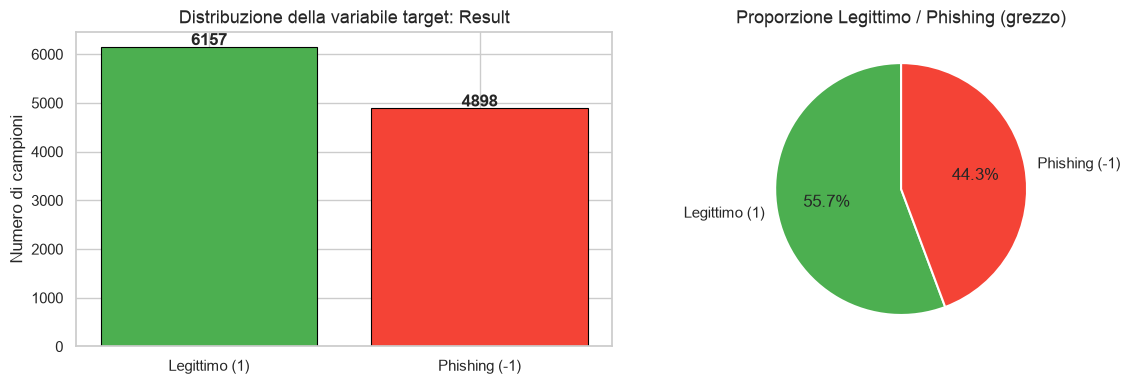

Legittimo  (1) : 6157 campioni (55.7%)
Phishing  (-1) : 4898 campioni (44.3%)


In [6]:
# Distribuzione del target
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

target_counts = df_raw['Result'].value_counts()
labels = ['Legittimo (1)', 'Phishing (-1)']
colors = ['#4CAF50', '#F44336']

axes[0].bar(labels, [target_counts[1], target_counts[-1]], color=colors, edgecolor='black', linewidth=0.8)
axes[0].set_title('Distribuzione della variabile target: Result', fontsize=13)
axes[0].set_ylabel('Numero di campioni')
for i, v in enumerate([target_counts[1], target_counts[-1]]):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].pie(
    [target_counts[1], target_counts[-1]],
    labels=labels,
    colors=colors,
    autopct='%1.1f%%',
    startangle=90,
    wedgeprops=dict(edgecolor='white', linewidth=1.5)
)
axes[1].set_title('Proporzione Legittimo / Phishing (grezzo)', fontsize=13)

plt.tight_layout()
plt.show()

print(f"Legittimo  (1) : {target_counts[1]} campioni ({target_counts[1]/len(df_raw)*100:.1f}%)")
print(f"Phishing  (-1) : {target_counts[-1]} campioni ({target_counts[-1]/len(df_raw)*100:.1f}%)")

=== VALORI MANCANTI PER COLONNA ===
Nessun valore mancante rilevato nel dataset grezzo.


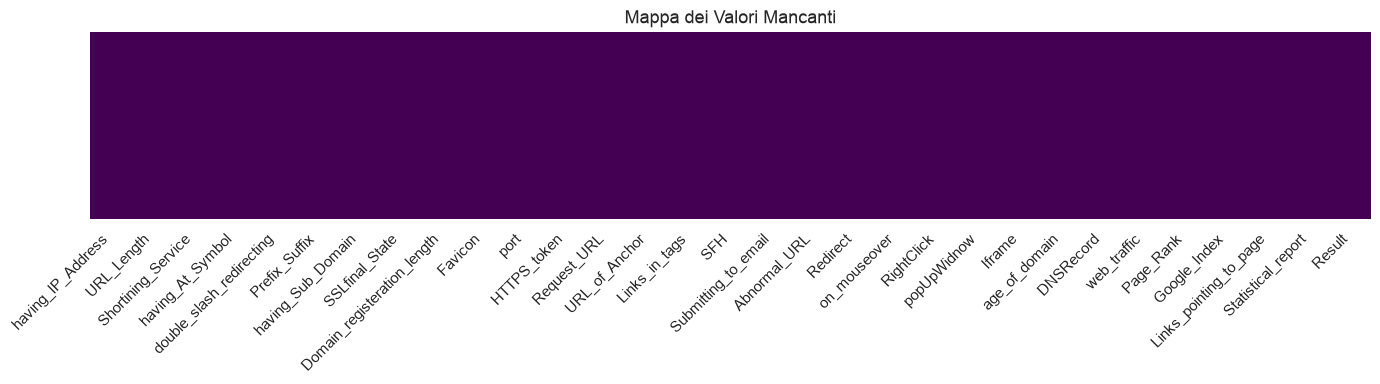

In [7]:
# Mappa dei valori mancanti
missing = df_raw.isnull().sum()
print('=== VALORI MANCANTI PER COLONNA ===')
print(missing[missing > 0] if missing.sum() > 0 else 'Nessun valore mancante rilevato nel dataset grezzo.')

plt.figure(figsize=(14, 4))
sns.heatmap(df_raw.isnull(), cbar=False, cmap='viridis', yticklabels=False)
plt.title('Mappa dei Valori Mancanti', fontsize=13)
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

In [8]:
# Analisi dei duplicati
n_dup = df_raw.duplicated().sum()
print(f'Righe duplicate nel dataset grezzo: {n_dup} ({n_dup/len(df_raw)*100:.1f}% del totale)')

Righe duplicate nel dataset grezzo: 5206 (47.1% del totale)


In [9]:
# Distribuzione delle feature (valori unici per colonna)
print('=== DOMINIO DEI VALORI PER FEATURE ===')
feature_domains = {}
for col in df_raw.columns:
    feature_domains[col] = sorted(df_raw[col].unique().tolist())
    print(f'  {col:35s}: {feature_domains[col]}')

=== DOMINIO DEI VALORI PER FEATURE ===
  having_IP_Address                  : [-1, 1]
  URL_Length                         : [-1, 0, 1]
  Shortining_Service                 : [-1, 1]
  having_At_Symbol                   : [-1, 1]
  double_slash_redirecting           : [-1, 1]
  Prefix_Suffix                      : [-1, 1]
  having_Sub_Domain                  : [-1, 0, 1]
  SSLfinal_State                     : [-1, 0, 1]
  Domain_registeration_length        : [-1, 1]
  Favicon                            : [-1, 1]
  port                               : [-1, 1]
  HTTPS_token                        : [-1, 1]
  Request_URL                        : [-1, 1]
  URL_of_Anchor                      : [-1, 0, 1]
  Links_in_tags                      : [-1, 0, 1]
  SFH                                : [-1, 0, 1]
  Submitting_to_email                : [-1, 1]
  Abnormal_URL                       : [-1, 1]
  Redirect                           : [0, 1]
  on_mouseover                       : [-1, 1]
  Ri

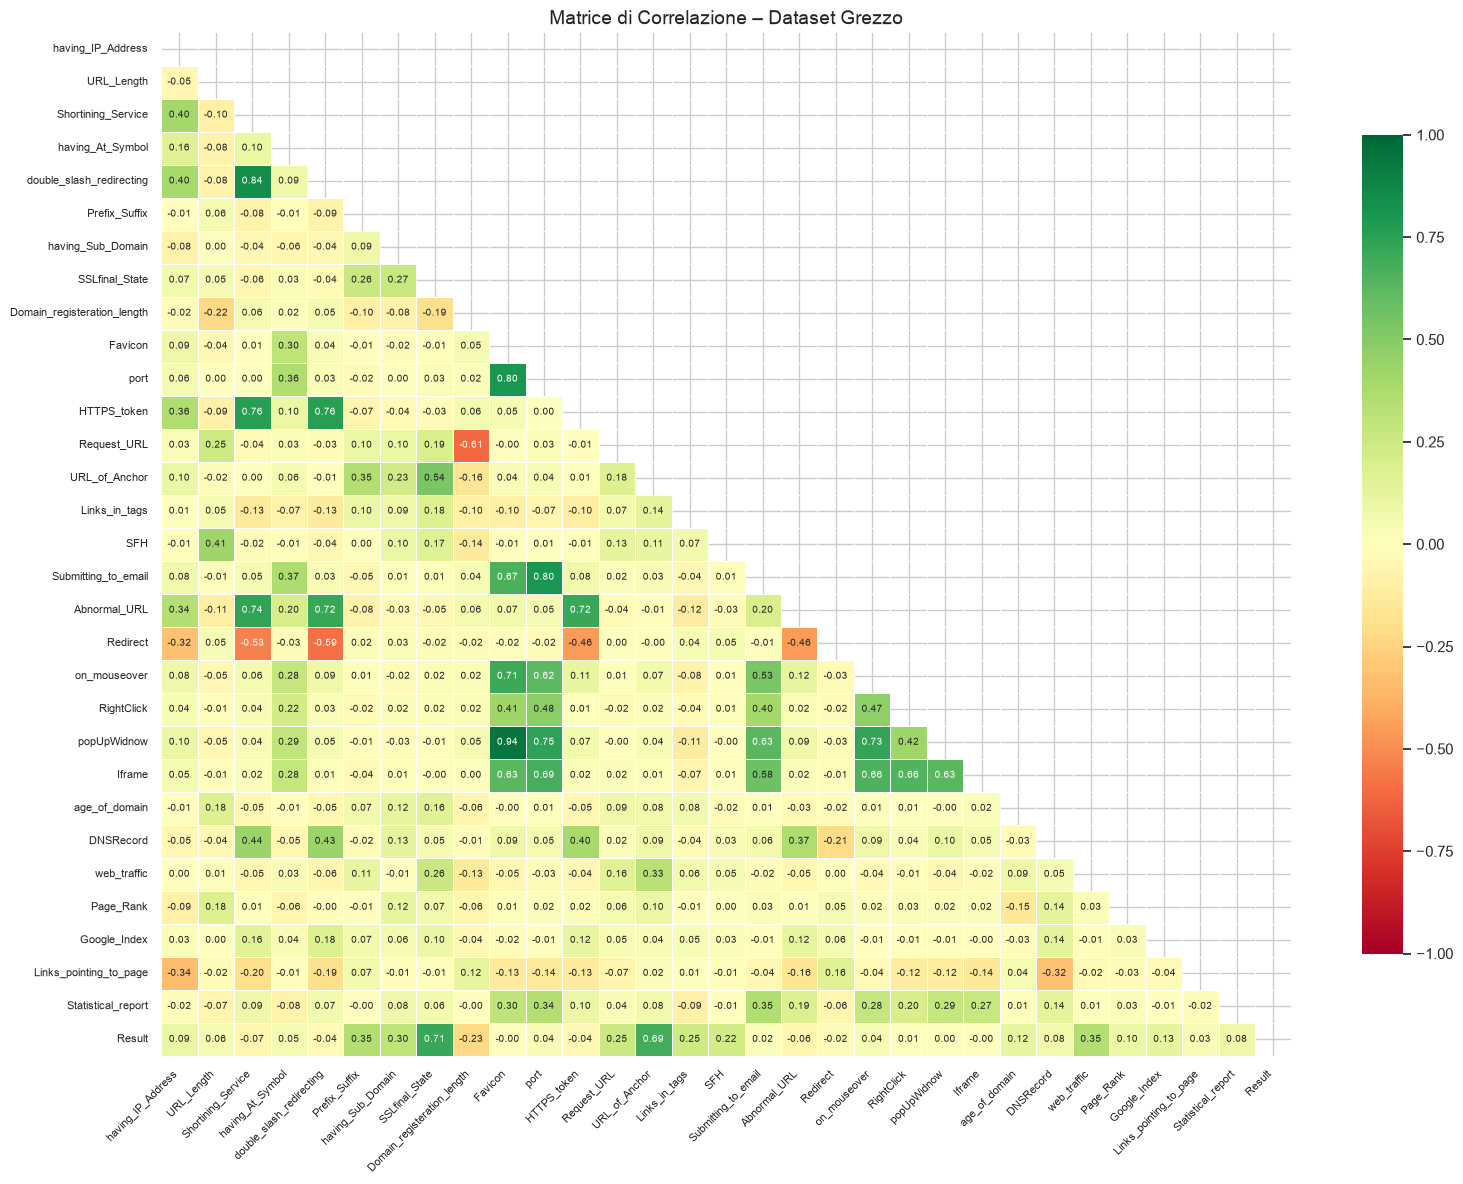

In [10]:
# Heatmap della correlazione (dataset grezzo)
plt.figure(figsize=(16, 12))
corr_matrix = df_raw.corr()
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(
    corr_matrix, mask=mask, annot=True, fmt='.2f',
    cmap='RdYlGn', center=0, vmin=-1, vmax=1,
    linewidths=0.5, cbar_kws={'shrink': 0.8},
    annot_kws={'size': 7}
)
plt.title('Matrice di Correlazione – Dataset Grezzo', fontsize=14)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.yticks(fontsize=8)
plt.tight_layout()
plt.show()

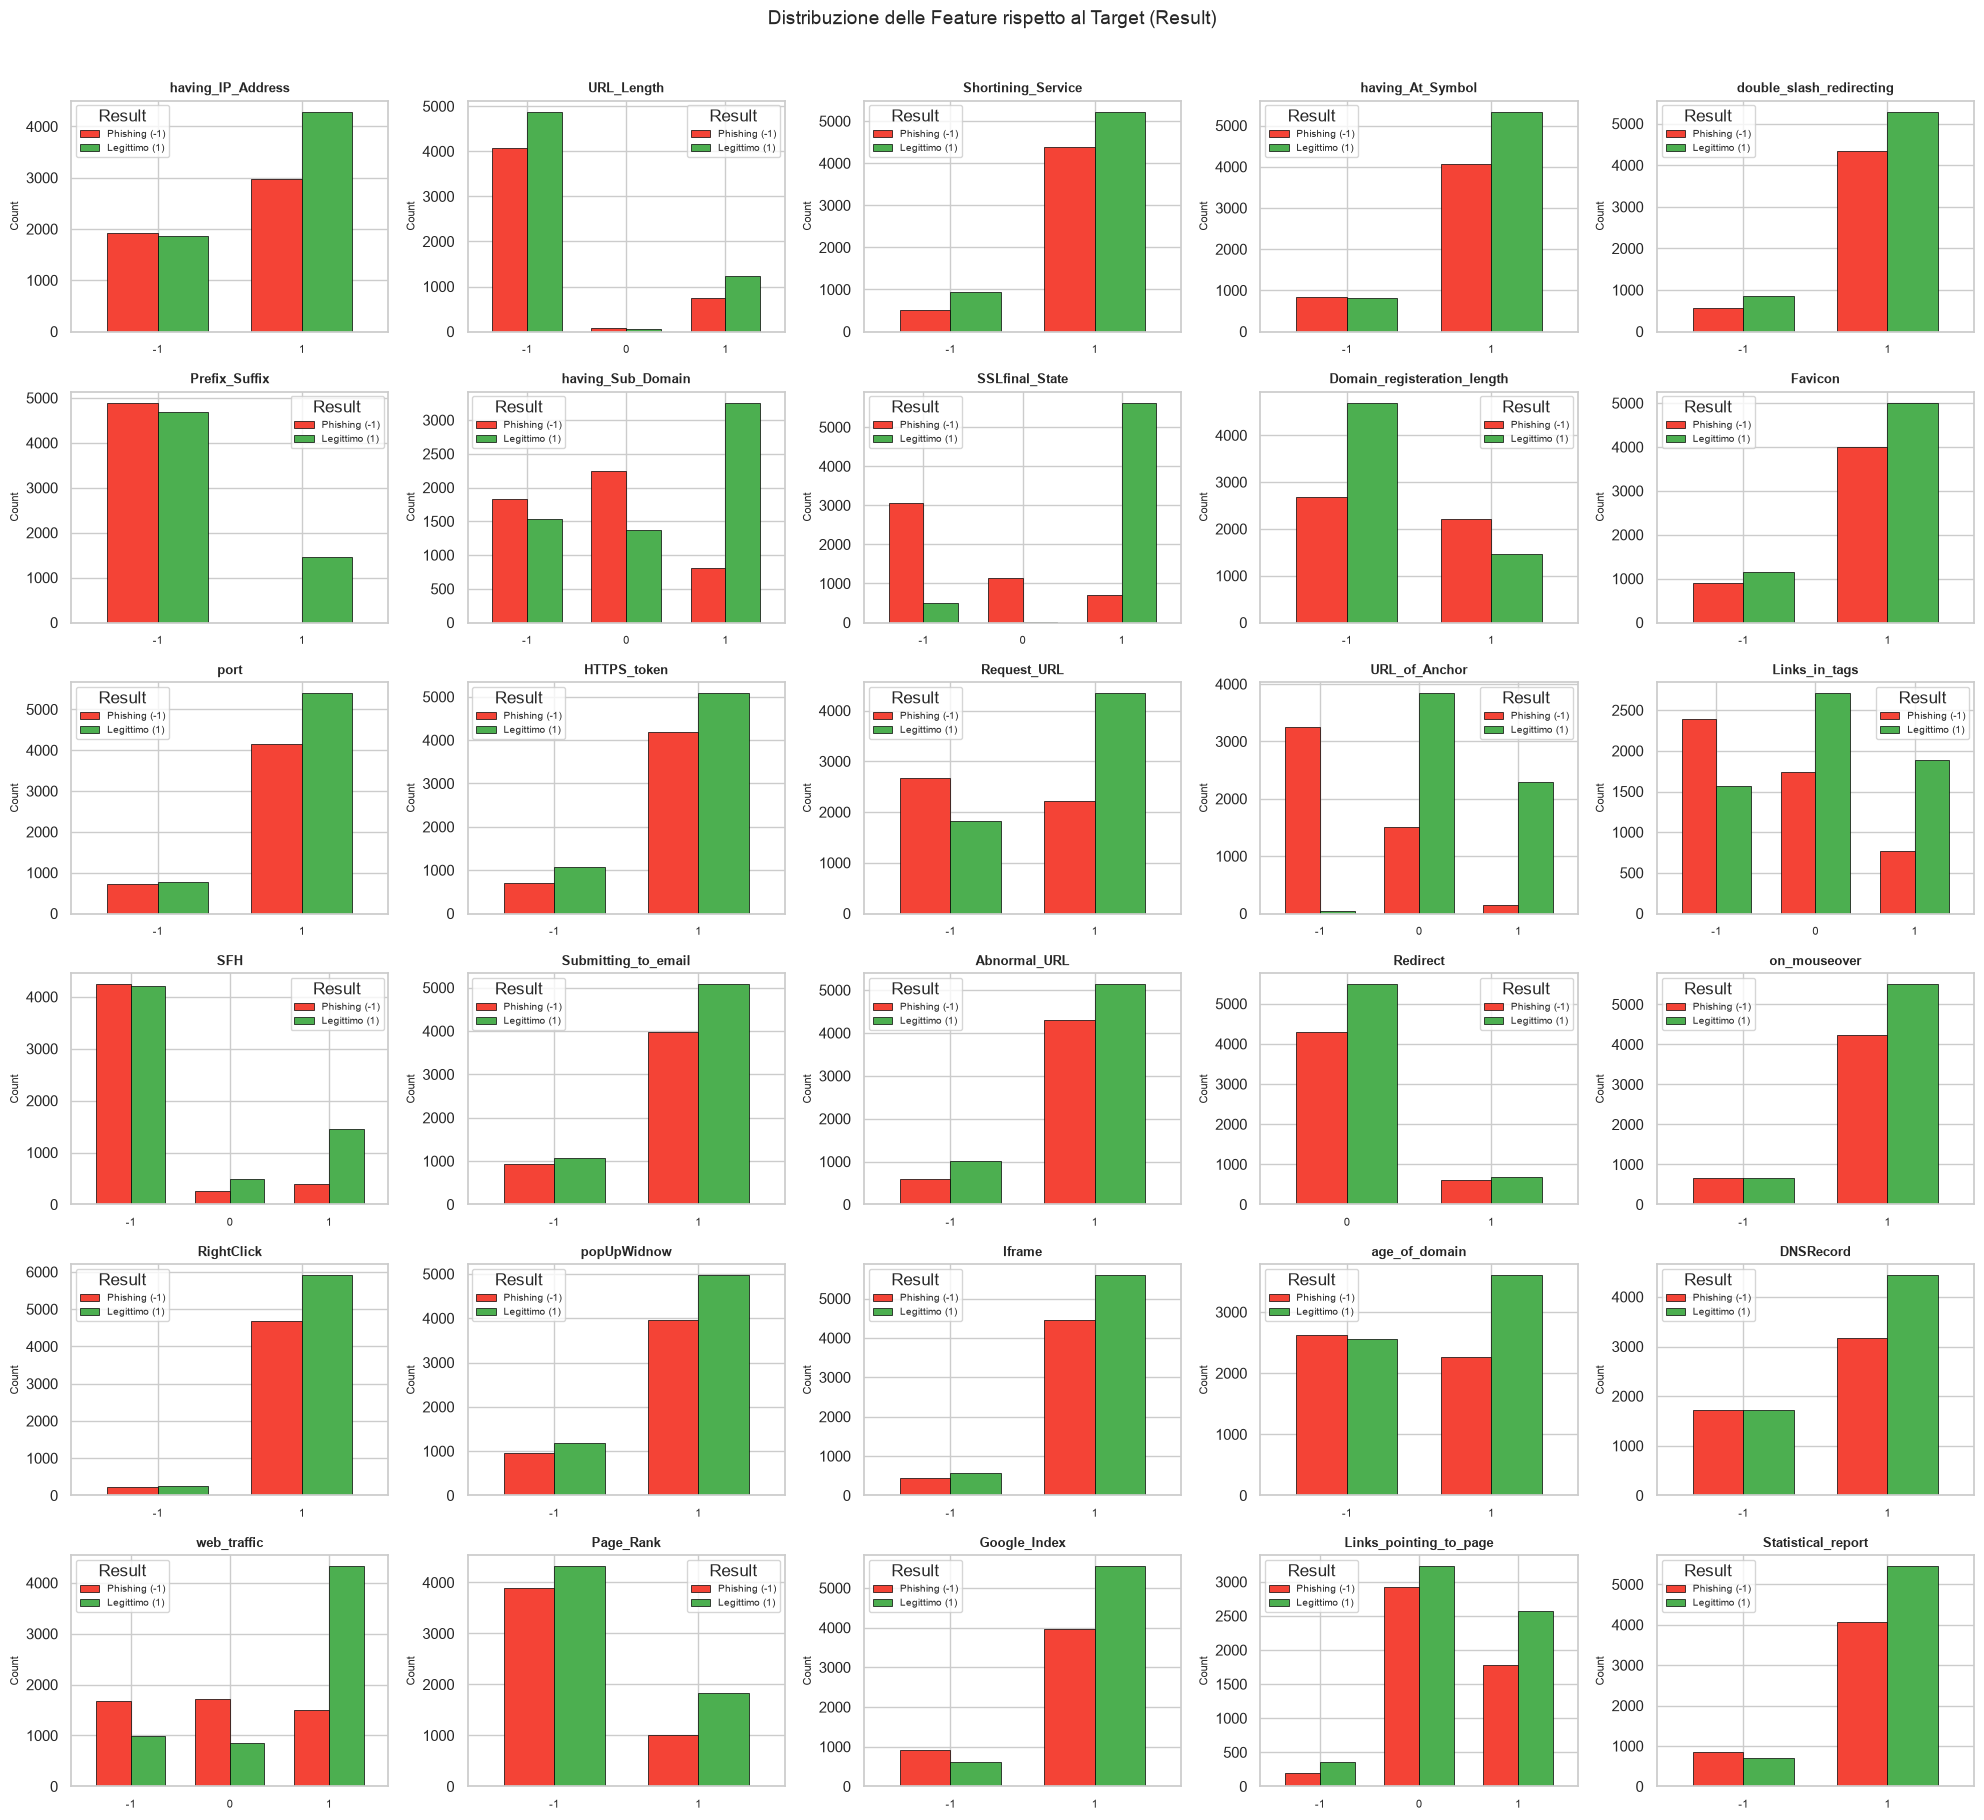

In [11]:
# Distribuzione delle feature rispetto al target
features = [c for c in df_raw.columns if c != 'Result']
n_cols = 5
n_rows = -(-len(features) // n_cols)  # ceil division

fig, axes = plt.subplots(n_rows, n_cols, figsize=(20, n_rows * 3))
axes = axes.flatten()

for i, feat in enumerate(features):
    ct = df_raw.groupby([feat, 'Result']).size().unstack(fill_value=0)
    ct.plot(kind='bar', ax=axes[i], color=['#F44336', '#4CAF50'], edgecolor='black', linewidth=0.5, width=0.7)
    axes[i].set_title(feat, fontsize=9, fontweight='bold')
    axes[i].set_xlabel('')
    axes[i].set_ylabel('Count', fontsize=8)
    axes[i].tick_params(axis='x', rotation=0, labelsize=8)
    axes[i].legend(title='Result', labels=['Phishing (-1)', 'Legittimo (1)'], fontsize=7)

for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.suptitle('Distribuzione delle Feature rispetto al Target (Result)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

## **4. Data Cleaning**

Questa è la fase principale del progetto. Il processo di pulizia dei dati si articola nei seguenti passi:

| Step | Tecnica | Motivazione |
|------|---------|-------------|
| 4.1 | Validazione del dominio dei valori | Verifica che ogni feature contenga solo valori ammessi secondo lo schema ARFF |
| 4.2 | Rimozione dei duplicati | 5206 righe duplicate (~47%) distorcono le distribuzioni e possono causare data leakage |
| 4.3 | Verifica e gestione dei valori mancanti | I NaN non sono evidenti ma potrebbero nascondersi come valori anomali |
| 4.4 | Rilevamento e gestione degli outlier | Con valori discreti, gli outlier si manifestano come violazioni del dominio |
| 4.5 | Verifica della consistenza inter-feature | Controllo di inconsistenze logiche tra feature correlate |
| 4.6 | Analisi della varianza (feature costanti o quasi) | Feature con varianza ~0 non apportano informazione predittiva |
| 4.7 | Analisi della correlazione | Rimozione di feature altamente correlate per ridurre la ridondanza |
| 4.8 | Report finale del cleaning | Riepilogo di tutte le operazioni effettuate |

In [12]:
# Lavoriamo su una copia del dataset grezzo
df = df_raw.copy()
cleaning_log = []  # Log delle operazioni di cleaning

print(f'Dataset grezzo: {df.shape[0]} righe x {df.shape[1]} colonne')

Dataset grezzo: 11055 righe x 31 colonne


### **4.1 – Validazione del Dominio dei Valori**

Ogni feature ha un dominio definito nello schema ARFF. Verifichiamo che non ci siano valori fuori dal dominio atteso.

In [13]:
# Domini attesi per ciascuna feature (da schema ARFF)
expected_domains = {
    'having_IP_Address': {-1, 1},
    'URL_Length': {-1, 0, 1},
    'Shortining_Service': {-1, 1},
    'having_At_Symbol': {-1, 1},
    'double_slash_redirecting': {-1, 1},
    'Prefix_Suffix': {-1, 1},
    'having_Sub_Domain': {-1, 0, 1},
    'SSLfinal_State': {-1, 0, 1},
    'Domain_registeration_length': {-1, 1},
    'Favicon': {-1, 1},
    'port': {-1, 1},
    'HTTPS_token': {-1, 1},
    'Request_URL': {-1, 1},
    'URL_of_Anchor': {-1, 0, 1},
    'Links_in_tags': {-1, 0, 1},
    'SFH': {-1, 0, 1},
    'Submitting_to_email': {-1, 1},
    'Abnormal_URL': {-1, 1},
    'Redirect': {0, 1},
    'on_mouseover': {-1, 1},
    'RightClick': {-1, 1},
    'popUpWidnow': {-1, 1},
    'Iframe': {-1, 1},
    'age_of_domain': {-1, 1},
    'DNSRecord': {-1, 1},
    'web_traffic': {-1, 0, 1},
    'Page_Rank': {-1, 1},
    'Google_Index': {-1, 1},
    'Links_pointing_to_page': {-1, 0, 1},
    'Statistical_report': {-1, 1},
    'Result': {-1, 1},
}

print('=== VALIDAZIONE DOMINIO DEI VALORI ===')
violations_found = False
violation_rows_all = set()

for col, domain in expected_domains.items():
    actual_values = set(df[col].unique())
    invalid_values = actual_values - domain
    if invalid_values:
        violations_found = True
        mask = ~df[col].isin(domain)
        n_violations = mask.sum()
        violation_rows_all.update(df[mask].index.tolist())
        print(f'  ❌ {col}: valori non validi {invalid_values} ({n_violations} righe)')
    else:
        print(f'  ✅ {col}: dominio corretto {sorted(domain)}')

if not violations_found:
    print('\n✅ Nessuna violazione del dominio rilevata. Tutti i valori sono conformi allo schema ARFF.')
else:
    print(f'\n⚠️  Totale righe con violazioni: {len(violation_rows_all)}')
    cleaning_log.append(f'Step 4.1 – Rimosse {len(violation_rows_all)} righe con violazioni del dominio')
    df = df[~df.index.isin(violation_rows_all)].reset_index(drop=True)

=== VALIDAZIONE DOMINIO DEI VALORI ===
  ✅ having_IP_Address: dominio corretto [-1, 1]
  ✅ URL_Length: dominio corretto [-1, 0, 1]
  ✅ Shortining_Service: dominio corretto [-1, 1]
  ✅ having_At_Symbol: dominio corretto [-1, 1]
  ✅ double_slash_redirecting: dominio corretto [-1, 1]
  ✅ Prefix_Suffix: dominio corretto [-1, 1]
  ✅ having_Sub_Domain: dominio corretto [-1, 0, 1]
  ✅ SSLfinal_State: dominio corretto [-1, 0, 1]
  ✅ Domain_registeration_length: dominio corretto [-1, 1]
  ✅ Favicon: dominio corretto [-1, 1]
  ✅ port: dominio corretto [-1, 1]
  ✅ HTTPS_token: dominio corretto [-1, 1]
  ✅ Request_URL: dominio corretto [-1, 1]
  ✅ URL_of_Anchor: dominio corretto [-1, 0, 1]
  ✅ Links_in_tags: dominio corretto [-1, 0, 1]
  ✅ SFH: dominio corretto [-1, 0, 1]
  ✅ Submitting_to_email: dominio corretto [-1, 1]
  ✅ Abnormal_URL: dominio corretto [-1, 1]
  ✅ Redirect: dominio corretto [0, 1]
  ✅ on_mouseover: dominio corretto [-1, 1]
  ✅ RightClick: dominio corretto [-1, 1]
  ✅ popUpWidno

### **4.2 – Rimozione dei Duplicati**

Il dataset grezzo contiene **5206 righe duplicate** (~47% del totale). Questo è un problema critico:
- Distorce le distribuzioni delle classi
- Introduce **data leakage** se record identici finiscono in train e test
- Può portare a overfitting sui modelli

Righe prima della deduplicazione: 11055
Righe duplicate rilevate:         5206 (47.1%)

Distribuzione target PRIMA della deduplicazione:
  Legittimo  (1): 6157 (55.7%)
  Phishing  (-1): 4898 (44.3%)

Righe dopo la deduplicazione:     5849
Righe rimosse:                    5206

Distribuzione target DOPO la deduplicazione:
  Legittimo  (1): 2830 (48.4%)
  Phishing  (-1): 3019 (51.6%)


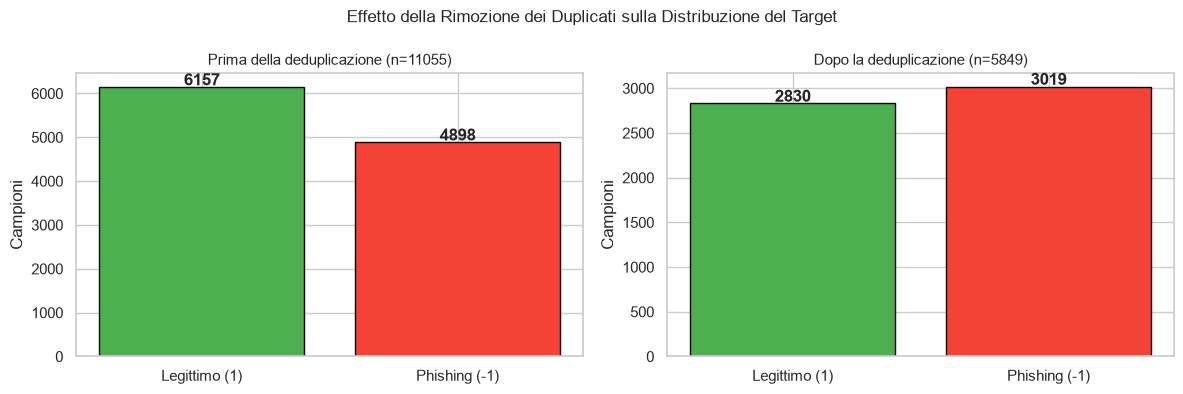

In [14]:
n_before = len(df)
n_dup = df.duplicated().sum()

print(f'Righe prima della deduplicazione: {n_before}')
print(f'Righe duplicate rilevate:         {n_dup} ({n_dup/n_before*100:.1f}%)')

# Distribuzione target prima della deduplicazione
print(f'\nDistribuzione target PRIMA della deduplicazione:')
vc_before = df['Result'].value_counts()
print(f'  Legittimo  (1): {vc_before.get(1, 0)} ({vc_before.get(1, 0)/n_before*100:.1f}%)')
print(f'  Phishing  (-1): {vc_before.get(-1, 0)} ({vc_before.get(-1, 0)/n_before*100:.1f}%)')

# Rimozione duplicati
df = df.drop_duplicates().reset_index(drop=True)
n_after = len(df)

print(f'\nRighe dopo la deduplicazione:     {n_after}')
print(f'Righe rimosse:                    {n_before - n_after}')

# Distribuzione target dopo la deduplicazione
print(f'\nDistribuzione target DOPO la deduplicazione:')
vc_after = df['Result'].value_counts()
print(f'  Legittimo  (1): {vc_after.get(1, 0)} ({vc_after.get(1, 0)/n_after*100:.1f}%)')
print(f'  Phishing  (-1): {vc_after.get(-1, 0)} ({vc_after.get(-1, 0)/n_after*100:.1f}%)')

cleaning_log.append(f'Step 4.2 – Rimosse {n_before - n_after} righe duplicate ({n_before - n_after}/{n_before} = {(n_before-n_after)/n_before*100:.1f}%)')

# Visualizzazione confronto
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
labels = ['Legittimo (1)', 'Phishing (-1)']
colors = ['#4CAF50', '#F44336']

vals_before = [vc_before.get(1, 0), vc_before.get(-1, 0)]
vals_after  = [vc_after.get(1, 0),  vc_after.get(-1, 0)]

axes[0].bar(labels, vals_before, color=colors, edgecolor='black')
axes[0].set_title(f'Prima della deduplicazione (n={n_before})', fontsize=11)
axes[0].set_ylabel('Campioni')
for i, v in enumerate(vals_before):
    axes[0].text(i, v + 30, str(v), ha='center', fontweight='bold')

axes[1].bar(labels, vals_after, color=colors, edgecolor='black')
axes[1].set_title(f'Dopo la deduplicazione (n={n_after})', fontsize=11)
axes[1].set_ylabel('Campioni')
for i, v in enumerate(vals_after):
    axes[1].text(i, v + 20, str(v), ha='center', fontweight='bold')

plt.suptitle('Effetto della Rimozione dei Duplicati sulla Distribuzione del Target', fontsize=12)
plt.tight_layout()
plt.show()

### **4.3 – Verifica e Gestione dei Valori Mancanti**

Verifichiamo l'assenza di NaN classici. Gli eventuali valori sentinella `0` nelle feature binarie {-1, 1} sono già stati rimossi in 4.1 come violazioni del dominio, quindi qui ci concentriamo sui NaN e sulla distribuzione del valore `0` nelle feature ternarie {-1, 0, 1}, dove `0` è semanticamente valido.

In [15]:
# Verifica NaN classici
nan_counts = df.isnull().sum()
print('=== VERIFICA VALORI MANCANTI (NaN) ===')
if nan_counts.sum() == 0:
    print('✅ Nessun valore NaN presente nel dataset.')
else:
    print(nan_counts[nan_counts > 0])

print()

# Nota: gli eventuali valori sentinella '0' nelle feature binarie {-1, 1} sono già
# stati intercettati e rimossi in 4.1 (validazione del dominio), dove 0 risulta
# fuori dominio. Qui non serve ricontrollarli.

# Distribuzione del valore '0' nelle feature ternarie {-1, 0, 1}, dove 0 è valido
ternary_features = [col for col, dom in expected_domains.items() if dom == {-1, 0, 1} and col != 'Result']
print('=== DISTRIBUZIONE DEL VALORE "0" NELLE FEATURE TERNARIE {-1, 0, 1} ===')
for col in ternary_features:
    n_zero = (df[col] == 0).sum()
    pct = n_zero / len(df) * 100
    print(f'  {col:35s}: {n_zero:5d} valori 0 ({pct:.1f}%)')

cleaning_log.append('Step 4.3 – Nessun NaN rilevato. I valori 0 nelle feature ternarie sono semanticamente validi.')


=== VERIFICA VALORI MANCANTI (NaN) ===
✅ Nessun valore NaN presente nel dataset.

=== DISTRIBUZIONE DEL VALORE "0" NELLE FEATURE TERNARIE {-1, 0, 1} ===
  URL_Length                         :    96 valori 0 (1.6%)
  having_Sub_Domain                  :  2058 valori 0 (35.2%)
  SSLfinal_State                     :   721 valori 0 (12.3%)
  URL_of_Anchor                      :  2655 valori 0 (45.4%)
  Links_in_tags                      :  2258 valori 0 (38.6%)
  SFH                                :   518 valori 0 (8.9%)
  web_traffic                        :  1539 valori 0 (26.3%)
  Links_pointing_to_page             :  3181 valori 0 (54.4%)


### **4.4 – Rilevamento e Gestione degli Outlier**

Trattandosi di feature categoriche con valori discreti in {-1, 0, 1}, gli outlier non si manifestano come valori numerici estremi, ma come **violazioni del dominio** (già gestite nel passo 4.1). 

Tuttavia, effettuiamo un'analisi statistica per identificare eventuali sbilanciamenti critici all'interno di ciascuna feature.

In [16]:
# Analisi della distribuzione di frequenza per ogni feature
print('=== DISTRIBUZIONE DI FREQUENZA DELLE FEATURE ===' )
print(f'{"Feature":<35} {"Valore":>8} {"Count":>8} {"% Totale":>10}')
print('-' * 65)

dominant_features = []  # Feature con un valore dominante > 90%

for col in df.columns:
    vc = df[col].value_counts(normalize=True).sort_index()
    for val, pct in vc.items():
        count = (df[col] == val).sum()
        flag = ' ⚠️' if pct > 0.90 else ''
        print(f'{col:<35} {str(val):>8} {count:>8} {pct*100:>9.1f}%{flag}')
    if vc.max() > 0.90:
        dominant_features.append((col, vc.idxmax(), vc.max()))
    print()

if dominant_features:
    print('\n=== FEATURE CON VALORE DOMINANTE (> 90%) ===')
    for feat, val, pct in dominant_features:
        print(f'  ⚠️  {feat}: valore {val} occorre nel {pct*100:.1f}% dei casi')
else:
    print('\n✅ Nessuna feature con valore dominante superiore al 90%.')

cleaning_log.append(f'Step 4.4 – Analisi outlier completata. Feature con valore dominante (>90%): {[f[0] for f in dominant_features] if dominant_features else "nessuna"}')

=== DISTRIBUZIONE DI FREQUENZA DELLE FEATURE ===
Feature                               Valore    Count   % Totale
-----------------------------------------------------------------
having_IP_Address                         -1     2536      43.4%
having_IP_Address                          1     3313      56.6%

URL_Length                                -1     4678      80.0%
URL_Length                                 0       96       1.6%
URL_Length                                 1     1075      18.4%

Shortining_Service                        -1      818      14.0%
Shortining_Service                         1     5031      86.0%

having_At_Symbol                          -1     1203      20.6%
having_At_Symbol                           1     4646      79.4%

double_slash_redirecting                  -1      824      14.1%
double_slash_redirecting                   1     5025      85.9%

Prefix_Suffix                             -1     5148      88.0%
Prefix_Suffix                      

### **4.5 – Verifica della Consistenza Inter-Feature**

Alcune feature del dataset sono logicamente correlate. Controlliamo se esistono combinazioni di valori che risultano inconsistenti dal punto di vista semantico.

=== VERIFICA CONSISTENZA SEMANTICA TRA FEATURE ===

Regola 1 – IP nell'URL + Dominio registrato a lungo termine:
  → 899 campioni potenzialmente inconsistenti (15.37%)
  Nota: può verificarsi (es. IP statico su dominio legittimo) – non rimossi automaticamente

Regola 2 – SSL valido + Token HTTPS assente nell'URL:
  → 555 campioni potenzialmente inconsistenti (9.49%)
  Nota: condizione ambigua – non rimossi automaticamente

Regola 3 – Non indicizzato da Google + Alto traffico web:
  → 511 campioni potenzialmente inconsistenti (8.74%)
  Nota: combinazione molto sospetta, ma potrebbe essere lag temporale – non rimossi automaticamente



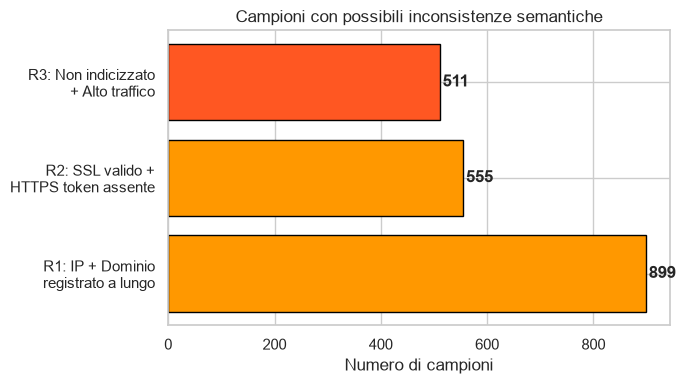

In [17]:
# Regole di consistenza semantica note nel dominio phishing:
# Regola 1: Se 'having_IP_Address' == -1 (IP nell'URL, tipico di phishing),
#            allora 'Domain_registeration_length' non dovrebbe essere 1 (dominio registrato a lungo termine)
# Regola 2: Se 'SSLfinal_State' == 1 (SSL valido), 'HTTPS_token' non dovrebbe essere -1 (HTTPS assente)
# Regola 3: Se 'Google_Index' == -1 (non indicizzato), 'web_traffic' non dovrebbe essere 1 (alto traffico)

print('=== VERIFICA CONSISTENZA SEMANTICA TRA FEATURE ===\n')

inconsistencies = {}

# Regola 1
rule1_mask = (df['having_IP_Address'] == -1) & (df['Domain_registeration_length'] == 1)
n_r1 = rule1_mask.sum()
inconsistencies['R1'] = n_r1
print(f'Regola 1 – IP nell\'URL + Dominio registrato a lungo termine:')
print(f'  → {n_r1} campioni potenzialmente inconsistenti ({n_r1/len(df)*100:.2f}%)')
print(f'  Nota: può verificarsi (es. IP statico su dominio legittimo) – non rimossi automaticamente\n')

# Regola 2
rule2_mask = (df['SSLfinal_State'] == 1) & (df['HTTPS_token'] == -1)
n_r2 = rule2_mask.sum()
inconsistencies['R2'] = n_r2
print(f'Regola 2 – SSL valido + Token HTTPS assente nell\'URL:')
print(f'  → {n_r2} campioni potenzialmente inconsistenti ({n_r2/len(df)*100:.2f}%)')
print(f'  Nota: condizione ambigua – non rimossi automaticamente\n')

# Regola 3
rule3_mask = (df['Google_Index'] == -1) & (df['web_traffic'] == 1)
n_r3 = rule3_mask.sum()
inconsistencies['R3'] = n_r3
print(f'Regola 3 – Non indicizzato da Google + Alto traffico web:')
print(f'  → {n_r3} campioni potenzialmente inconsistenti ({n_r3/len(df)*100:.2f}%)')
print(f'  Nota: combinazione molto sospetta, ma potrebbe essere lag temporale – non rimossi automaticamente\n')

# Visualizzazione
fig, ax = plt.subplots(figsize=(7, 4))
rule_labels = [
    'R1: IP + Dominio\nregistrato a lungo',
    'R2: SSL valido +\nHTTPS token assente',
    'R3: Non indicizzato\n+ Alto traffico'
]
rule_counts = [n_r1, n_r2, n_r3]
bars = ax.barh(rule_labels, rule_counts, color=['#FF9800', '#FF9800', '#FF5722'], edgecolor='black')
ax.set_xlabel('Numero di campioni')
ax.set_title('Campioni con possibili inconsistenze semantiche', fontsize=12)
for bar, count in zip(bars, rule_counts):
    ax.text(bar.get_width() + 5, bar.get_y() + bar.get_height()/2, str(count), va='center', fontweight='bold')
plt.tight_layout()
plt.show()

cleaning_log.append(f'Step 4.5 – Verifica consistenza: R1={n_r1}, R2={n_r2}, R3={n_r3} campioni sospetti (conservati per analisi successiva)')

### **4.6 – Analisi della Varianza (Feature Quasi-Costanti)**

Feature con varianza molto bassa (o nulla) non contribuiscono alla capacità predittiva del modello e vengono rimosse.

=== VARIANZA DELLE FEATURE (ordine crescente) ===
  Redirect                           : 0.1145
  RightClick                         : 0.1867
  Links_pointing_to_page             : 0.3353
  Iframe                             : 0.3829
  Prefix_Suffix                      : 0.4220
  on_mouseover                       : 0.4773
  Shortining_Service                 : 0.4813
  double_slash_redirecting           : 0.4842
  Statistical_report                 : 0.5142
  URL_of_Anchor                      : 0.5270
  Abnormal_URL                       : 0.5401
  port                               : 0.5410
  Google_Index                       : 0.5621
  SFH                                : 0.5698
  HTTPS_token                        : 0.5729
  Links_in_tags                      : 0.5925
  URL_Length                         : 0.6042
  having_Sub_Domain                  : 0.6439
  having_At_Symbol                   : 0.6536
  Favicon                            : 0.6616
  Submitting_to_email         

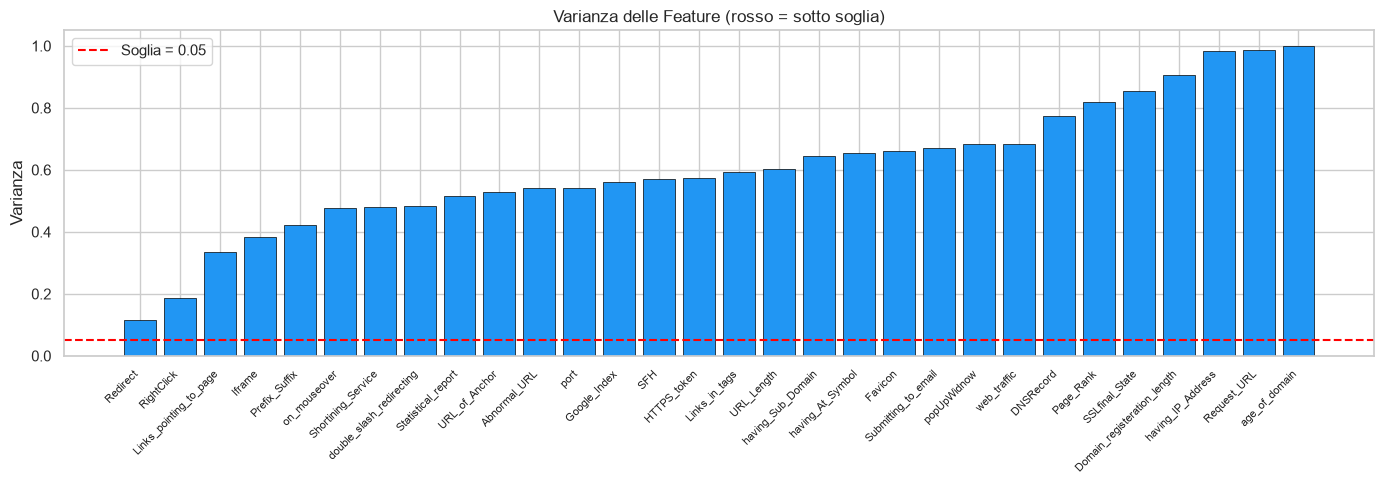

In [18]:
# Calcolo della varianza per ogni feature
feature_cols = [c for c in df.columns if c != 'Result']
variances = df[feature_cols].var().sort_values()

print('=== VARIANZA DELLE FEATURE (ordine crescente) ===')
for col, var in variances.items():
    flag = ' ⚠️  QUASI-COSTANTE' if var < 0.05 else ''
    print(f'  {col:<35}: {var:.4f}{flag}')

# Soglia per feature quasi-costanti
VAR_THRESHOLD = 0.05
low_var_features = variances[variances < VAR_THRESHOLD].index.tolist()

print(f'\n=== FEATURE CON VARIANZA < {VAR_THRESHOLD} ===')
if low_var_features:
    for feat in low_var_features:
        print(f'  ❌ Rimossa: {feat} (varianza = {variances[feat]:.4f})')
    df = df.drop(columns=low_var_features)
    cleaning_log.append(f'Step 4.6 – Rimosse {len(low_var_features)} feature quasi-costanti: {low_var_features}')
else:
    print(f'  ✅ Nessuna feature con varianza inferiore alla soglia {VAR_THRESHOLD}.')
    cleaning_log.append(f'Step 4.6 – Nessuna feature quasi-costante rilevata (soglia={VAR_THRESHOLD}).')

# Visualizzazione varianze
plt.figure(figsize=(14, 5))
colors_var = ['#F44336' if v < VAR_THRESHOLD else '#2196F3' for v in variances.values]
bars = plt.bar(variances.index, variances.values, color=colors_var, edgecolor='black', linewidth=0.5)
plt.axhline(y=VAR_THRESHOLD, color='red', linestyle='--', linewidth=1.5, label=f'Soglia = {VAR_THRESHOLD}')
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('Varianza')
plt.title('Varianza delle Feature (rosso = sotto soglia)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.show()

### **4.7 – Analisi della Correlazione e Rimozione Feature Ridondanti**

Feature fortemente correlate tra loro sono ridondanti: forniscono informazioni simili al modello aumentando la complessità senza migliorare le prestazioni. Rimuoviamo una delle due feature in ogni coppia con correlazione |r| > 0.85.

=== COPPIE DI FEATURE CON CORRELAZIONE |r| > 0.85 ===
  |r|=0.933  popUpWidnow ↔ Favicon
    → Rimuovo: popUpWidnow (corr. con target=0.022)
    → Mantengo: Favicon (corr. con target=0.025)


Feature rimanenti dopo il cleaning: 29


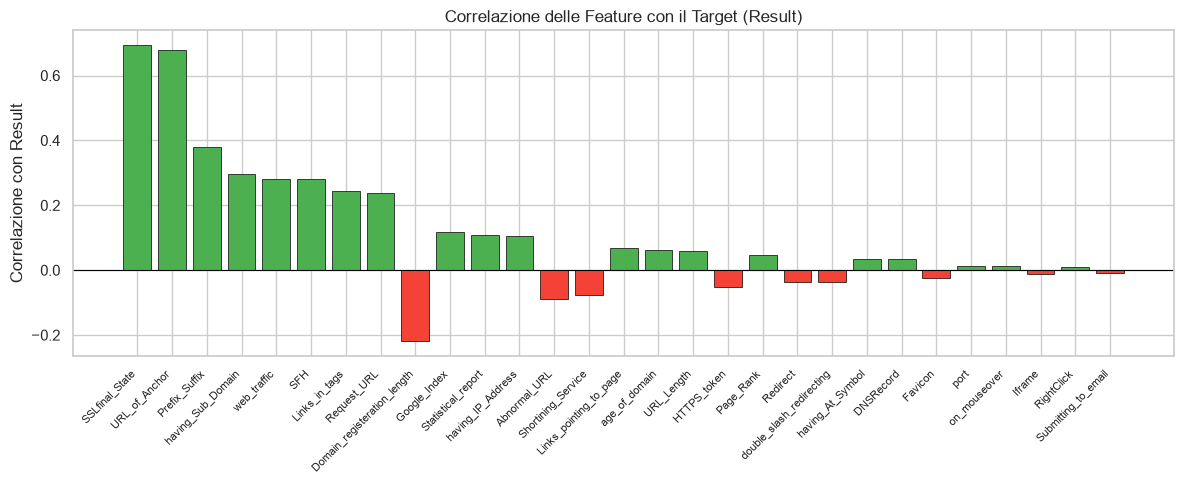

In [19]:
# Calcolo matrice di correlazione sulle sole feature (post cleaning)
feature_cols_clean = [c for c in df.columns if c != 'Result']
corr_matrix = df[feature_cols_clean].corr().abs()

# Individuazione coppie con correlazione alta
CORR_THRESHOLD = 0.85
upper_tri = corr_matrix.where(np.triu(np.ones(corr_matrix.shape), k=1).astype(bool))
high_corr_pairs = [(col, row, upper_tri.loc[row, col])
                   for col in upper_tri.columns
                   for row in upper_tri.index
                   if pd.notna(upper_tri.loc[row, col]) and upper_tri.loc[row, col] > CORR_THRESHOLD]

print(f'=== COPPIE DI FEATURE CON CORRELAZIONE |r| > {CORR_THRESHOLD} ===')
to_drop_corr = set()

if high_corr_pairs:
    for f1, f2, corr_val in sorted(high_corr_pairs, key=lambda x: -x[2]):
        # Manteniamo la feature più correlata con il target
        corr_f1_target = abs(df[f1].corr(df['Result']))
        corr_f2_target = abs(df[f2].corr(df['Result']))
        drop_col = f2 if corr_f1_target >= corr_f2_target else f1
        keep_col = f1 if drop_col == f2 else f2
        to_drop_corr.add(drop_col)
        print(f'  |r|={corr_val:.3f}  {f1} ↔ {f2}')
        print(f'    → Rimuovo: {drop_col} (corr. con target={min(corr_f1_target, corr_f2_target):.3f})')
        print(f'    → Mantengo: {keep_col} (corr. con target={max(corr_f1_target, corr_f2_target):.3f})\n')
    
    if to_drop_corr:
        df = df.drop(columns=list(to_drop_corr))
        cleaning_log.append(f'Step 4.7 – Rimosse {len(to_drop_corr)} feature ad alta correlazione (soglia={CORR_THRESHOLD}): {list(to_drop_corr)}')
else:
    print(f'  ✅ Nessuna coppia di feature con correlazione superiore alla soglia {CORR_THRESHOLD}.')
    cleaning_log.append(f'Step 4.7 – Nessuna feature ridondante rilevata (soglia correlazione={CORR_THRESHOLD}).')

print(f'\nFeature rimanenti dopo il cleaning: {len([c for c in df.columns if c != "Result"])}')

# Correlazione delle feature rimaste con il target
corr_with_target = df.corr()['Result'].drop('Result').sort_values(key=abs, ascending=False)
plt.figure(figsize=(12, 5))
colors_target = ['#4CAF50' if v > 0 else '#F44336' for v in corr_with_target.values]
plt.bar(corr_with_target.index, corr_with_target.values, color=colors_target, edgecolor='black', linewidth=0.5)
plt.axhline(0, color='black', linewidth=0.8)
plt.xticks(rotation=45, ha='right', fontsize=8)
plt.ylabel('Correlazione con Result')
plt.title('Correlazione delle Feature con il Target (Result)', fontsize=12)
plt.tight_layout()
plt.show()

### **4.8 – Report Finale del Data Cleaning**

In [20]:
print('=' * 65)
print('           REPORT FINALE – DATA CLEANING')
print('=' * 65)
print(f'\nDataset grezzo:  {df_raw.shape[0]:6d} righe  x  {df_raw.shape[1]:2d} feature')
print(f'Dataset pulito:  {df.shape[0]:6d} righe  x  {df.shape[1]:2d} feature (target incluso)')
print(f'\nRighe rimosse:   {df_raw.shape[0] - df.shape[0]:6d}  ({(df_raw.shape[0]-df.shape[0])/df_raw.shape[0]*100:.1f}%)')
print(f'Feature rimosse: {df_raw.shape[1] - df.shape[1]:6d}')
print()
print('Operazioni eseguite:')
for i, log in enumerate(cleaning_log, 1):
    print(f'  {i}. {log}')
print()
print('Distribuzione finale del target:')
vc_final = df['Result'].value_counts()
print(f'  Legittimo  (1): {vc_final.get(1, 0):5d} ({vc_final.get(1, 0)/len(df)*100:.1f}%)')
print(f'  Phishing  (-1): {vc_final.get(-1, 0):5d} ({vc_final.get(-1, 0)/len(df)*100:.1f}%)')
print()
print('Feature nel dataset pulito:')
print([c for c in df.columns if c != 'Result'])
print('=' * 65)

df_clean = df.copy()
print('\nPrime righe del dataset pulito:')
df_clean.head()

           REPORT FINALE – DATA CLEANING

Dataset grezzo:   11055 righe  x  31 feature
Dataset pulito:    5849 righe  x  30 feature (target incluso)

Righe rimosse:     5206  (47.1%)
Feature rimosse:      1

Operazioni eseguite:
  1. Step 4.2 – Rimosse 5206 righe duplicate (5206/11055 = 47.1%)
  2. Step 4.3 – Nessun NaN rilevato. I valori 0 nelle feature ternarie sono semanticamente validi.
  3. Step 4.4 – Analisi outlier completata. Feature con valore dominante (>90%): ['RightClick']
  4. Step 4.5 – Verifica consistenza: R1=899, R2=555, R3=511 campioni sospetti (conservati per analisi successiva)
  5. Step 4.6 – Nessuna feature quasi-costante rilevata (soglia=0.05).
  6. Step 4.7 – Rimosse 1 feature ad alta correlazione (soglia=0.85): ['popUpWidnow']

Distribuzione finale del target:
  Legittimo  (1):  2830 (48.4%)
  Phishing  (-1):  3019 (51.6%)

Feature nel dataset pulito:
['having_IP_Address', 'URL_Length', 'Shortining_Service', 'having_At_Symbol', 'double_slash_redirecting', 'Pref

,having_IP_Address,URL_Length,Shortining_Service,having_At_Symbol,double_slash_redirecting,Prefix_Suffix,having_Sub_Domain,SSLfinal_State,Domain_registeration_length,Favicon,...,RightClick,Iframe,age_of_domain,DNSRecord,web_traffic,Page_Rank,Google_Index,Links_pointing_to_page,Statistical_report,Result
0,-1,1,1,1,-1,-1,-1,-1,-1,1,...,1,1,-1,-1,-1,-1,1,1,-1,-1
1,1,1,1,1,1,-1,0,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,-1
2,1,0,1,1,1,-1,-1,-1,-1,1,...,1,1,1,-1,1,-1,1,0,-1,-1
3,1,0,1,1,1,-1,-1,-1,1,1,...,1,1,-1,-1,1,-1,1,-1,1,-1
4,1,0,-1,1,1,-1,1,1,-1,1,...,1,1,-1,-1,0,-1,1,1,1,1


## **5. Feature Engineering**

Dopo il cleaning, separiamo feature e target e applichiamo la standardizzazione per i modelli che ne hanno bisogno (KNN, Logistic Regression).

In [21]:
# Separazione feature e target
target = 'Result'
X = df_clean.drop(columns=[target])
y = df_clean[target]

print(f'Feature (X): {X.shape[1]} colonne')
print(f'Target  (y): distribuzione → {dict(y.value_counts())}')

Feature (X): 29 colonne
Target  (y): distribuzione → {-1: np.int64(3019), 1: np.int64(2830)}


# **Fase 3 — Sviluppo dei Modelli Predittivi**

Split train/test (il test set è usato solo per la valutazione finale), bilanciamento del **solo** training con SMOTE, addestramento di tre modelli, feature selection, modelli avanzati, validazione incrociata k-fold e hyperparameter tuning con Grid/Randomized Search. Le metriche di valutazione (Accuracy, Precision, Recall, F1, confusion matrix) sono riportate inline per ciascun modello.

## **6. Train-Test Split**

In [22]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f'Training set:  {X_train.shape[0]} campioni')
print(f'Test set:      {X_test.shape[0]} campioni')
print(f'\nDistribuzione y_train: {dict(y_train.value_counts())}')
print(f'Distribuzione y_test:  {dict(y_test.value_counts())}')

Training set:  4679 campioni
Test set:      1170 campioni

Distribuzione y_train: {-1: np.int64(2415), 1: np.int64(2264)}
Distribuzione y_test:  {-1: np.int64(604), 1: np.int64(566)}


## **7. Bilanciamento del Dataset di Training con SMOTE**

Anche dopo il cleaning il dataset presenta uno sbilanciamento moderato. Applichiamo SMOTE **solo sul training set** per evitare data leakage.

In [23]:
print(f'Distribuzione classi PRIMA di SMOTE: {Counter(y_train)}')

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

print(f'Distribuzione classi DOPO SMOTE:     {Counter(y_train_res)}')

# Scaling
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled  = scaler.transform(X_test)

print(f'\nScaling applicato: StandardScaler (fit su training, transform su test)')

Distribuzione classi PRIMA di SMOTE: Counter({-1: 2415, 1: 2264})
Distribuzione classi DOPO SMOTE:     Counter({-1: 2415, 1: 2415})

Scaling applicato: StandardScaler (fit su training, transform su test)


## **8. Addestramento e Valutazione dei Modelli**

Addestriamo tre modelli di classificazione:
- **Decision Tree** (non richiede scaling)
- **Logistic Regression**
- **K-Nearest Neighbors**

Valutiamo ciascun modello con: Accuracy, Precision, Recall, F1-Score e Confusion Matrix.
Infine, combiniamo le previsioni tramite **Majority Vote (Ensemble)**.
Questi saranno i modelli _baseline_ che verranno usati come benchmark per modelli più avanzati.

=== VALUTAZIONE DEI MODELLI INDIVIDUALI ===

--- Decision Tree ---
  Accuracy:  0.9188
  Precision: 0.9188
  Recall:    0.9188
  F1-Score:  0.9188

--- Logistic Regression ---
  Accuracy:  0.9120
  Precision: 0.9123
  Recall:    0.9120
  F1-Score:  0.9120

--- K-Nearest Neighbors ---
  Accuracy:  0.9179
  Precision: 0.9180
  Recall:    0.9179
  F1-Score:  0.9179



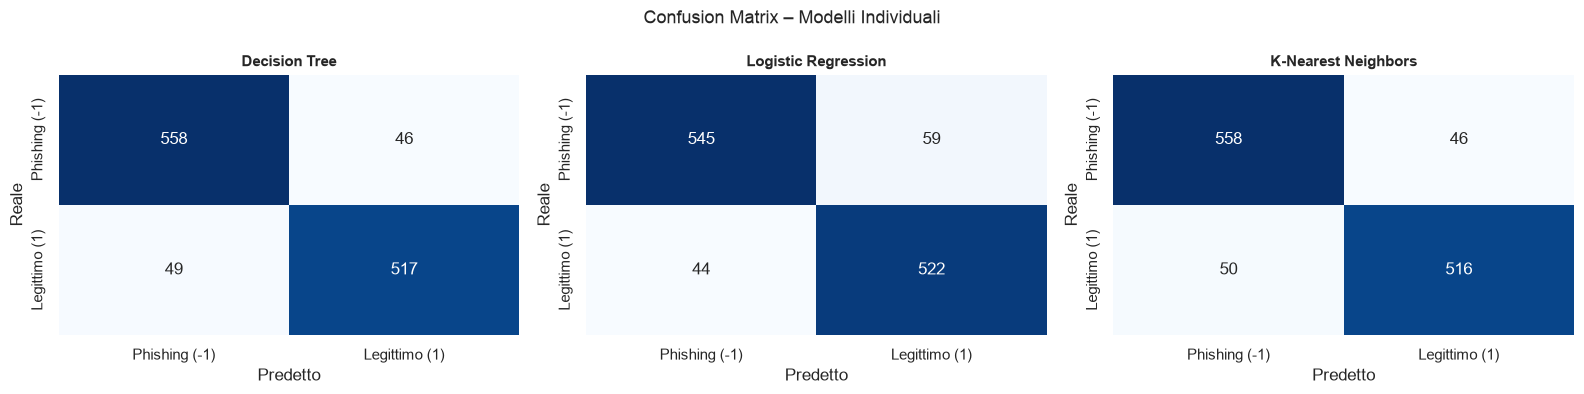

In [24]:
def plot_confusion_matrix(y_true, y_pred, title='Confusion Matrix', ax=None):
    cm = confusion_matrix(y_true, y_pred)
    if ax is None:
        fig, ax = plt.subplots(figsize=(5, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False, ax=ax,
                xticklabels=['Phishing (-1)', 'Legittimo (1)'],
                yticklabels=['Phishing (-1)', 'Legittimo (1)'])
    ax.set_title(title, fontsize=11, fontweight='bold')
    ax.set_xlabel('Predetto')
    ax.set_ylabel('Reale')


models = {
    'Decision Tree':     DecisionTreeClassifier(criterion='entropy', random_state=0),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=0),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
}

predictions = {}
results = []

fig, axes = plt.subplots(1, len(models), figsize=(16, 4))

print('=== VALUTAZIONE DEI MODELLI INDIVIDUALI ===\n')
for ax, (name, model) in zip(axes, models.items()):
    model.fit(X_train_scaled, y_train_res)
    y_pred = model.predict(X_test_scaled)
    predictions[name] = y_pred

    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')
    results.append({'Modello': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

    plot_confusion_matrix(y_test, y_pred, title=f'{name}', ax=ax)
    print(f'--- {name} ---')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}\n')

plt.suptitle('Confusion Matrix – Modelli Individuali', fontsize=13)
plt.tight_layout()
plt.show()

--- Ensemble – Majority Vote ---
  Accuracy:  0.9342
  Precision: 0.9343
  Recall:    0.9342
  F1-Score:  0.9342


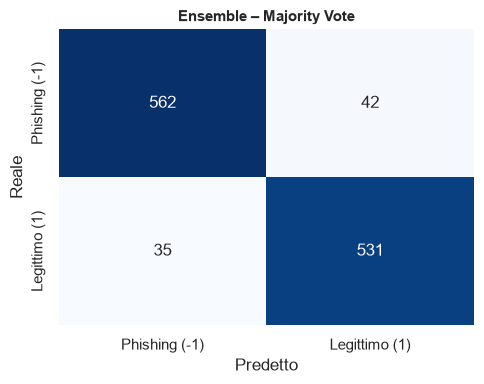

In [25]:
# Ensemble – Majority Vote
def majority_vote(predictions_dict):
    preds = np.array(list(predictions_dict.values()))
    majority_votes = []
    for i in range(preds.shape[1]):
        vals, counts = np.unique(preds[:, i], return_counts=True)
        majority_votes.append(vals[np.argmax(counts)])
    return np.array(majority_votes)

y_pred_ensemble = majority_vote(predictions)

acc_ens  = accuracy_score(y_test, y_pred_ensemble)
prec_ens = precision_score(y_test, y_pred_ensemble, average='weighted')
rec_ens  = recall_score(y_test, y_pred_ensemble, average='weighted')
f1_ens   = f1_score(y_test, y_pred_ensemble, average='weighted')
results.append({'Modello': 'Ensemble (Majority Vote)', 'Accuracy': acc_ens, 'Precision': prec_ens, 'Recall': rec_ens, 'F1-Score': f1_ens})

print('--- Ensemble – Majority Vote ---')
print(f'  Accuracy:  {acc_ens:.4f}')
print(f'  Precision: {prec_ens:.4f}')
print(f'  Recall:    {rec_ens:.4f}')
print(f'  F1-Score:  {f1_ens:.4f}')

fig, ax = plt.subplots(figsize=(5, 4))
plot_confusion_matrix(y_test, y_pred_ensemble, title='Ensemble – Majority Vote', ax=ax)
plt.tight_layout()
plt.show()

=== RIEPILOGO METRICHE ===
                          Accuracy  Precision  Recall  F1-Score
Modello                                                        
Decision Tree               0.9188     0.9188  0.9188    0.9188
Logistic Regression         0.9120     0.9123  0.9120    0.9120
K-Nearest Neighbors         0.9179     0.9180  0.9179    0.9179
Ensemble (Majority Vote)    0.9342     0.9343  0.9342    0.9342


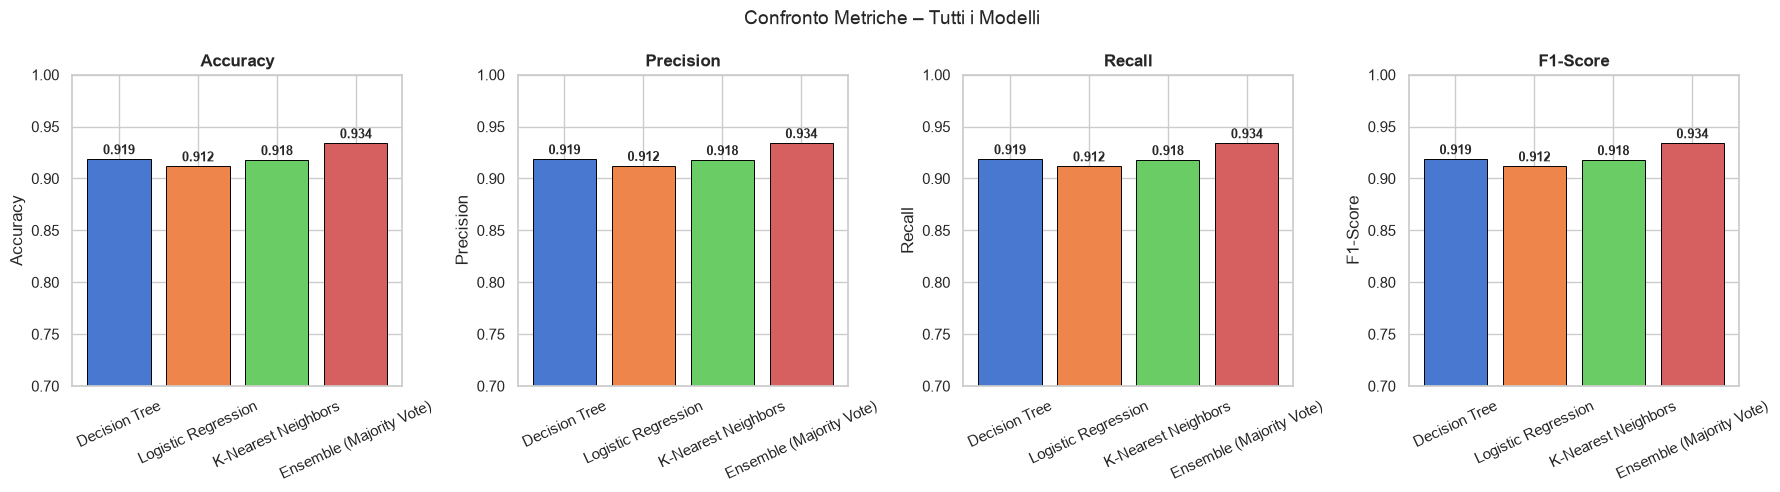

In [26]:
# Tabella riepilogativa dei risultati
results_df = pd.DataFrame(results).set_index('Modello')
print('=== RIEPILOGO METRICHE ===')
print(results_df.to_string(float_format='{:.4f}'.format))

# Barplot comparativo
fig, axes = plt.subplots(1, 4, figsize=(18, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
palette = sns.color_palette('muted', len(results_df))

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df.index, results_df[metric], color=palette, edgecolor='black', linewidth=0.7)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0.7, 1.0)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=25)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002, f'{h:.3f}', ha='center', va='bottom', fontsize=9, fontweight='bold')

plt.suptitle('Confronto Metriche – Tutti i Modelli', fontsize=14)
plt.tight_layout()
plt.show()

## **9. Feature Selection Automatizzata**

Implementiamo due tecniche di selezione automatica delle feature per identificare le variabili realmente informative e ridurre eventuale rumore:

- **9.1 – Importanza delle feature (Random Forest)**: un Random Forest stima l'importanza di ciascuna feature in base alla riduzione media dell'impurità (Gini).
- **9.2 – Recursive Feature Elimination (RFE)**: elimina iterativamente le feature meno rilevanti, mantenendo solo le più predittive.

L'obiettivo è capire **quali feature contano di più** e confrontare l'accordo tra i due metodi.

=== IMPORTANZA DELLE FEATURE (Random Forest, Gini) ===
  SSLfinal_State                  : 0.3397
  URL_of_Anchor                   : 0.2141
  having_Sub_Domain               : 0.0637
  Prefix_Suffix                   : 0.0533
  web_traffic                     : 0.0528
  Links_in_tags                   : 0.0434
  SFH                             : 0.0314
  Request_URL                     : 0.0198
  Links_pointing_to_page          : 0.0193
  Domain_registeration_length     : 0.0176
  age_of_domain                   : 0.0150
  having_IP_Address               : 0.0149
  Google_Index                    : 0.0140
  Page_Rank                       : 0.0132
  DNSRecord                       : 0.0107
  URL_Length                      : 0.0090
  having_At_Symbol                : 0.0071
  Redirect                        : 0.0070
  Favicon                         : 0.0067
  Statistical_report              : 0.0066
  Submitting_to_email             : 0.0065
  HTTPS_token                     : 0.0060

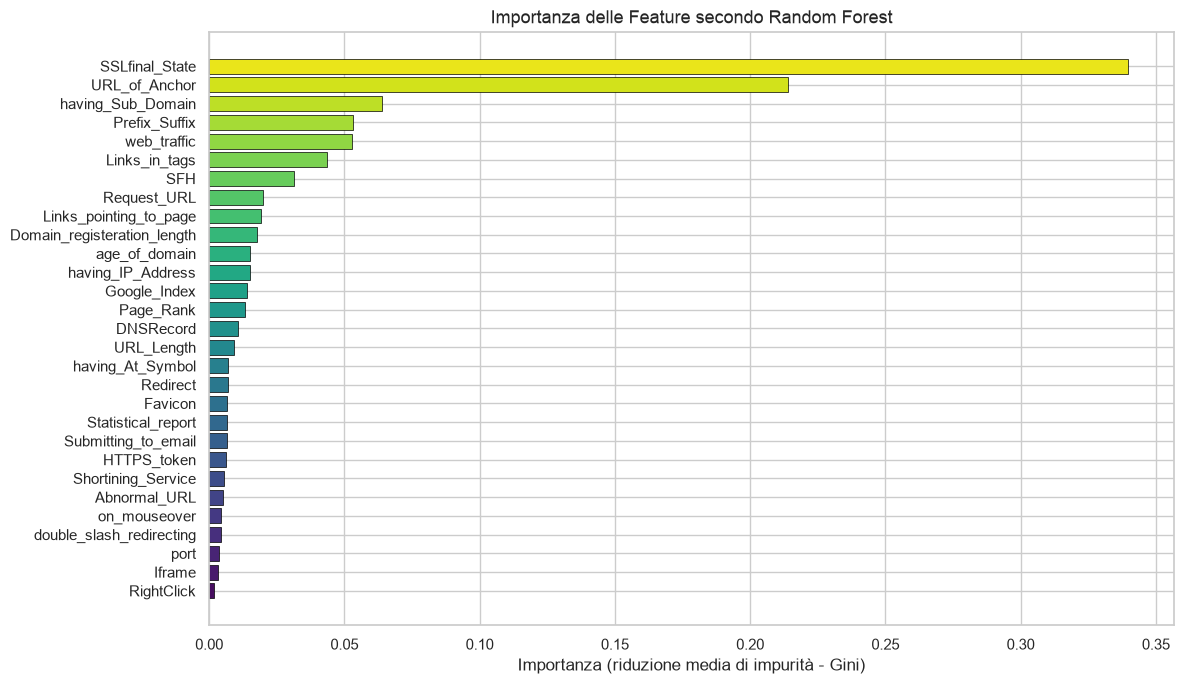

In [28]:
# Import aggiuntivi per la sezione miglioramenti
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.feature_selection import RFE
from sklearn.model_selection import cross_val_score, StratifiedKFold, GridSearchCV, RandomizedSearchCV
from sklearn.preprocessing import LabelEncoder
from imblearn.pipeline import Pipeline as ImbPipeline
from xgboost import XGBClassifier
from scipy.stats import randint, uniform

# --- 9.1 Importanza delle feature con Random Forest ---
rf_fs = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=2)
rf_fs.fit(X_train_res, y_train_res)

importances = pd.Series(rf_fs.feature_importances_, index=X.columns).sort_values(ascending=False)

print('=== IMPORTANZA DELLE FEATURE (Random Forest, Gini) ===')
for feat, imp in importances.items():
    print(f'  {feat:<32}: {imp:.4f}')

plt.figure(figsize=(12, 7))
colors_imp = sns.color_palette('viridis', len(importances))
plt.barh(importances.index[::-1], importances.values[::-1],
         color=colors_imp, edgecolor='black', linewidth=0.5)
plt.xlabel('Importanza (riduzione media di impurità - Gini)')
plt.title('Importanza delle Feature secondo Random Forest', fontsize=13)
plt.tight_layout()
plt.show()

### **9.2 – Recursive Feature Elimination (RFE)**

RFE addestra ripetutamente un modello, rimuovendo a ogni passo la feature meno importante, fino a mantenere solo le `N` più rilevanti. Usiamo un Random Forest come stimatore di base.

In [29]:
# --- 9.2 Recursive Feature Elimination (RFE) ---
N_FEATURES_RFE = 15
rfe = RFE(
    estimator=RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=2),
    n_features_to_select=N_FEATURES_RFE,
    step=2
)
rfe.fit(X_train_res, y_train_res)

selected_features = X.columns[rfe.support_].tolist()
discarded_features = [c for c in X.columns if c not in selected_features]

print(f'=== RFE - Selezione delle {N_FEATURES_RFE} feature piu rilevanti ===\n')
print('Feature SELEZIONATE:')
for f in selected_features:
    print(f'  [OK] {f}')
print('\nFeature SCARTATE:')
for f in discarded_features:
    print(f'  [--] {f}')

# Confronto: quante delle top-15 per importanza RF coincidono con quelle scelte da RFE
top15_rf = set(importances.head(N_FEATURES_RFE).index)
agreement = len(top15_rf & set(selected_features))
print(f'\nAccordo tra Random Forest (top {N_FEATURES_RFE}) e RFE: '
      f'{agreement}/{N_FEATURES_RFE} feature in comune '
      f'({agreement/N_FEATURES_RFE*100:.0f}%)')

=== RFE - Selezione delle 15 feature piu rilevanti ===

Feature SELEZIONATE:
  [OK] having_IP_Address
  [OK] Prefix_Suffix
  [OK] having_Sub_Domain
  [OK] SSLfinal_State
  [OK] Domain_registeration_length
  [OK] Request_URL
  [OK] URL_of_Anchor
  [OK] Links_in_tags
  [OK] SFH
  [OK] age_of_domain
  [OK] DNSRecord
  [OK] web_traffic
  [OK] Page_Rank
  [OK] Google_Index
  [OK] Links_pointing_to_page

Feature SCARTATE:
  [--] URL_Length
  [--] Shortining_Service
  [--] having_At_Symbol
  [--] double_slash_redirecting
  [--] Favicon
  [--] port
  [--] HTTPS_token
  [--] Submitting_to_email
  [--] Abnormal_URL
  [--] Redirect
  [--] on_mouseover
  [--] RightClick
  [--] Iframe
  [--] Statistical_report

Accordo tra Random Forest (top 15) e RFE: 15/15 feature in comune (100%)


## **10. Modelli Avanzati: Random Forest, Gradient Boosting, XGBoost**

Affianchiamo ai tre modelli base tre algoritmi di tipo **ensemble** più sofisticati, generalmente più performanti su dati tabellari:

- **Random Forest** – bagging di alberi decisionali, robusto e poco soggetto a overfitting.
- **Gradient Boosting** – boosting sequenziale che corregge gli errori dei modelli precedenti.
- **XGBoost** – implementazione ottimizzata del gradient boosting, spesso lo stato dell'arte sui dati tabellari.

Questi modelli ad albero **non richiedono lo scaling**, quindi vengono addestrati direttamente sui dati ribilanciati con SMOTE. XGBoost richiede etichette in `{0, 1}`, quindi codifichiamo il target con un `LabelEncoder`.

=== VALUTAZIONE DEI MODELLI AVANZATI ===

--- Random Forest ---
  Accuracy:  0.9410
  Precision: 0.9412
  Recall:    0.9410
  F1-Score:  0.9410

--- Gradient Boosting ---
  Accuracy:  0.9462
  Precision: 0.9464
  Recall:    0.9462
  F1-Score:  0.9462

--- XGBoost ---
  Accuracy:  0.9530
  Precision: 0.9530
  Recall:    0.9530
  F1-Score:  0.9530



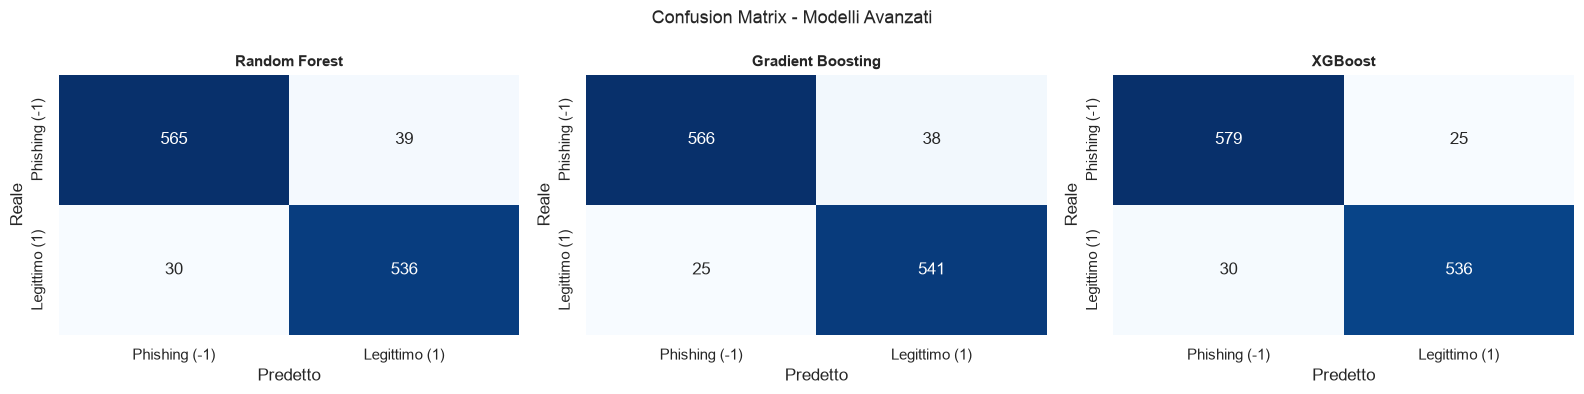

In [30]:
# Encoding del target per XGBoost (richiede etichette in {0, 1})
le = LabelEncoder()
y_train_res_enc = le.fit_transform(y_train_res)   # -1 -> 0, 1 -> 1

advanced_models = {
    'Random Forest':     RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=2),
    'Gradient Boosting': GradientBoostingClassifier(random_state=42),
    'XGBoost':           XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                                       eval_metric='logloss', random_state=42, n_jobs=2),
}

print('=== VALUTAZIONE DEI MODELLI AVANZATI ===\n')
fig, axes = plt.subplots(1, len(advanced_models), figsize=(16, 4))

for ax, (name, model) in zip(axes, advanced_models.items()):
    if name == 'XGBoost':
        model.fit(X_train_res, y_train_res_enc)
        y_pred = le.inverse_transform(model.predict(X_test))
    else:
        model.fit(X_train_res, y_train_res)
        y_pred = model.predict(X_test)

    predictions[name] = y_pred
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')
    results.append({'Modello': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})

    plot_confusion_matrix(y_test, y_pred, title=name, ax=ax)
    print(f'--- {name} ---')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}\n')

plt.suptitle('Confusion Matrix - Modelli Avanzati', fontsize=13)
plt.tight_layout()
plt.show()

### **10.1 – Confronto Aggiornato di Tutti i Modelli**

Aggiorniamo la tabella riepilogativa includendo i modelli base, l'ensemble e i nuovi modelli avanzati.

=== RIEPILOGO METRICHE - TUTTI I MODELLI ===
                          Accuracy  Precision  Recall  F1-Score
Modello                                                        
Decision Tree               0.9188     0.9188  0.9188    0.9188
Logistic Regression         0.9120     0.9123  0.9120    0.9120
K-Nearest Neighbors         0.9179     0.9180  0.9179    0.9179
Ensemble (Majority Vote)    0.9342     0.9343  0.9342    0.9342
Random Forest               0.9410     0.9412  0.9410    0.9410
Gradient Boosting           0.9462     0.9464  0.9462    0.9462
XGBoost                     0.9530     0.9530  0.9530    0.9530


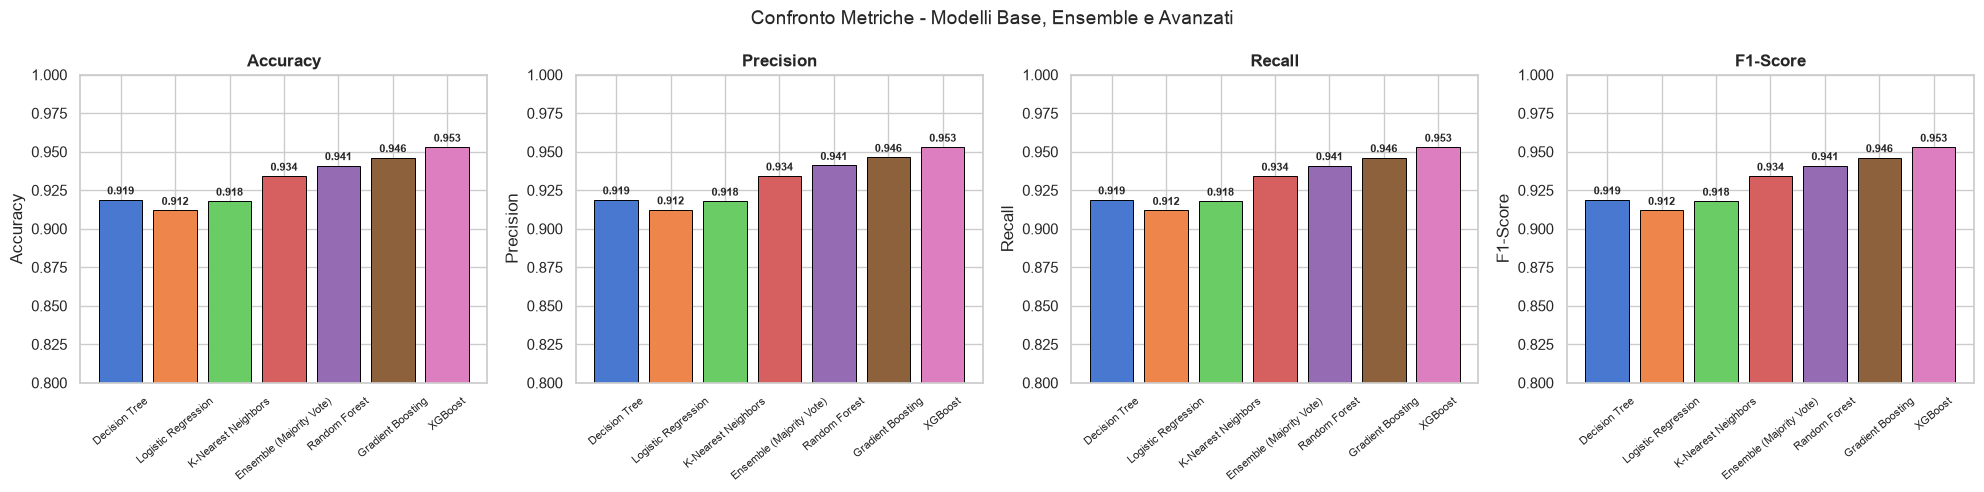


Miglior modello per F1-Score: XGBoost (0.9530)


In [31]:
# Tabella riepilogativa aggiornata (rimuove eventuali duplicati da ri-esecuzioni)
results_df = (pd.DataFrame(results)
              .drop_duplicates('Modello', keep='last')
              .set_index('Modello'))

print('=== RIEPILOGO METRICHE - TUTTI I MODELLI ===')
print(results_df.to_string(float_format='{:.4f}'.format))

# Barplot comparativo
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
metrics = ['Accuracy', 'Precision', 'Recall', 'F1-Score']
palette = sns.color_palette('muted', len(results_df))

for ax, metric in zip(axes, metrics):
    bars = ax.bar(results_df.index, results_df[metric], color=palette, edgecolor='black', linewidth=0.7)
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0.8, 1.0)
    ax.set_ylabel(metric)
    ax.tick_params(axis='x', rotation=40, labelsize=8)
    for bar in bars:
        h = bar.get_height()
        ax.text(bar.get_x() + bar.get_width()/2, h + 0.002, f'{h:.3f}',
                ha='center', va='bottom', fontsize=8, fontweight='bold')

plt.suptitle('Confronto Metriche - Modelli Base, Ensemble e Avanzati', fontsize=14)
plt.tight_layout()
plt.show()

# Migliore modello per F1-Score
best_model_name = results_df['F1-Score'].idxmax()
print(f'\nMiglior modello per F1-Score: {best_model_name} ({results_df.loc[best_model_name, "F1-Score"]:.4f})')

## **11. Validazione Incrociata (k-fold Cross-Validation)**

Un singolo train-test split può dare una stima fortunata o sfortunata delle prestazioni. La **k-fold cross-validation** fornisce una stima più robusta, addestrando e valutando il modello su `k` partizioni diverse dei dati.

**Punto metodologico importante:** per evitare *data leakage*, SMOTE (e lo scaling) vengono inseriti **dentro** una `Pipeline` di `imblearn`, così il ribilanciamento viene ricalcolato a ogni fold usando solo i dati di training di quel fold — mai i dati di validazione. Usiamo `StratifiedKFold` per mantenere le proporzioni delle classi in ogni fold.

=== CROSS-VALIDATION (5-fold stratificata, scoring = F1 weighted) ===

  Decision Tree         : 0.9288 +/- 0.0051
  Logistic Regression   : 0.9226 +/- 0.0126
  K-Nearest Neighbors   : 0.9205 +/- 0.0091
  Random Forest         : 0.9427 +/- 0.0068
  Gradient Boosting     : 0.9432 +/- 0.0072
  XGBoost               : 0.9483 +/- 0.0035


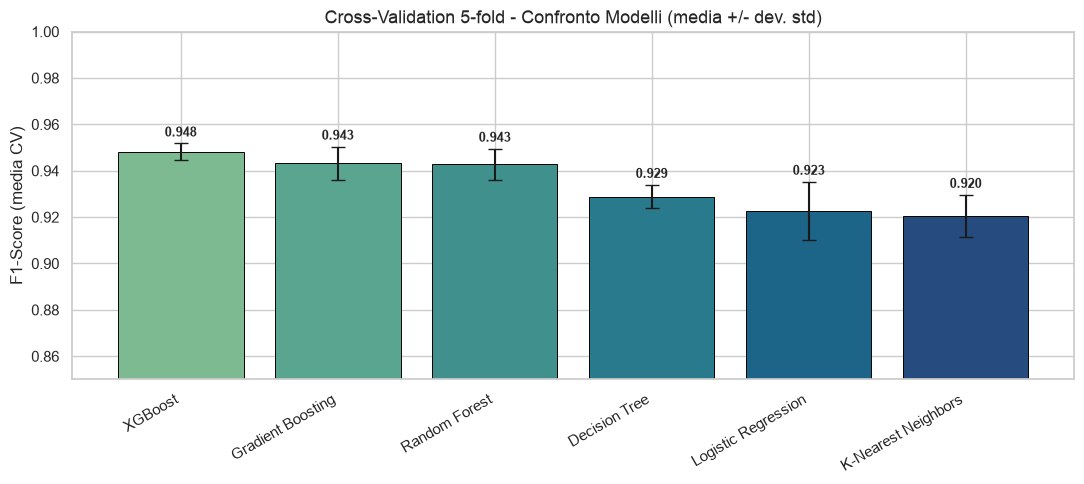

In [32]:
# Stratified 5-fold CV con pipeline imblearn (SMOTE/scaling dentro la CV -> niente leakage)
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
y_train_xgb = LabelEncoder().fit_transform(y_train)  # {-1,1} -> {0,1} per XGBoost

cv_models = {
    'Decision Tree':       DecisionTreeClassifier(criterion='entropy', random_state=0),
    'Logistic Regression': LogisticRegression(max_iter=1000, random_state=0),
    'K-Nearest Neighbors': KNeighborsClassifier(n_neighbors=5),
    'Random Forest':       RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=2),
    'Gradient Boosting':   GradientBoostingClassifier(random_state=42),
    'XGBoost':             XGBClassifier(n_estimators=200, learning_rate=0.1, max_depth=6,
                                         eval_metric='logloss', random_state=42, n_jobs=2),
}

print('=== CROSS-VALIDATION (5-fold stratificata, scoring = F1 weighted) ===\n')
cv_results = []
for name, model in cv_models.items():
    steps = [('smote', SMOTE(random_state=42))]
    # Lo scaling serve solo ai modelli sensibili alla scala
    if name in ('Logistic Regression', 'K-Nearest Neighbors'):
        steps.append(('scaler', StandardScaler()))
    steps.append(('clf', model))
    pipe = ImbPipeline(steps)

    target = y_train_xgb if name == 'XGBoost' else y_train
    scores = cross_val_score(pipe, X_train, target, cv=cv, scoring='f1_weighted', n_jobs=2)
    cv_results.append({'Modello': name, 'F1 media': scores.mean(), 'Dev. std': scores.std()})
    print(f'  {name:<22}: {scores.mean():.4f} +/- {scores.std():.4f}')

cv_df = pd.DataFrame(cv_results).set_index('Modello').sort_values('F1 media', ascending=False)

# Visualizzazione con barre di errore
plt.figure(figsize=(11, 5))
order = cv_df.index
colors_cv = sns.color_palette('crest', len(order))
plt.bar(order, cv_df['F1 media'], yerr=cv_df['Dev. std'], capsize=5,
        color=colors_cv, edgecolor='black', linewidth=0.7)
plt.ylim(0.85, 1.0)
plt.ylabel('F1-Score (media CV)')
plt.title('Cross-Validation 5-fold - Confronto Modelli (media +/- dev. std)', fontsize=13)
plt.xticks(rotation=30, ha='right')
for i, (m, row) in enumerate(cv_df.iterrows()):
    plt.text(i, row['F1 media'] + row['Dev. std'] + 0.003, f"{row['F1 media']:.3f}",
             ha='center', fontsize=9, fontweight='bold')
plt.tight_layout()
plt.show()

## **12. Hyperparameter Tuning**

Ottimizziamo gli iperparametri dei due modelli più promettenti:

- **Random Forest** con `GridSearchCV` (ricerca esaustiva su una griglia).
- **XGBoost** con `RandomizedSearchCV` (campionamento casuale, più efficiente su spazi ampi).

Entrambe le ricerche usano la stessa pipeline con SMOTE interno e la `StratifiedKFold` definita sopra, così l'ottimizzazione è coerente con la validazione e priva di leakage.

In [33]:
# --- 12.1 GridSearchCV per Random Forest ---
rf_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   RandomForestClassifier(random_state=42, n_jobs=1)),
])
rf_grid = {
    'clf__n_estimators':      [100, 200],
    'clf__max_depth':         [None, 10],
    'clf__min_samples_split': [2, 5],
}
grid_rf = GridSearchCV(rf_pipe, rf_grid, cv=cv, scoring='f1_weighted', n_jobs=2, verbose=0)
grid_rf.fit(X_train, y_train)

print('=== GridSearchCV - Random Forest ===')
print('Migliori parametri:', grid_rf.best_params_)
print(f'Miglior F1 (CV):    {grid_rf.best_score_:.4f}')

=== GridSearchCV - Random Forest ===
Migliori parametri: {'clf__max_depth': None, 'clf__min_samples_split': 5, 'clf__n_estimators': 100}
Miglior F1 (CV):    0.9455


In [34]:
# --- 12.2 RandomizedSearchCV per XGBoost ---
xgb_pipe = ImbPipeline([
    ('smote', SMOTE(random_state=42)),
    ('clf',   XGBClassifier(eval_metric='logloss', random_state=42, n_jobs=1)),
])
xgb_dist = {
    'clf__n_estimators':  randint(150, 350),
    'clf__max_depth':     randint(3, 9),
    'clf__learning_rate': uniform(0.01, 0.3),
    'clf__subsample':     uniform(0.7, 0.3),
}
rand_xgb = RandomizedSearchCV(xgb_pipe, xgb_dist, n_iter=10, cv=cv,
                              scoring='f1_weighted', random_state=42, n_jobs=2, verbose=0)
rand_xgb.fit(X_train, y_train_xgb)

print('=== RandomizedSearchCV - XGBoost ===')
print('Migliori parametri:', rand_xgb.best_params_)
print(f'Miglior F1 (CV):    {rand_xgb.best_score_:.4f}')

=== RandomizedSearchCV - XGBoost ===
Migliori parametri: {'clf__learning_rate': np.float64(0.30766346778736525), 'clf__max_depth': 3, 'clf__n_estimators': 207, 'clf__subsample': np.float64(0.8574269294896713)}
Miglior F1 (CV):    0.9517


### **12.3 – Valutazione dei Modelli Ottimizzati sul Test Set**

Confrontiamo i modelli ottimizzati con le rispettive versioni di default, valutandoli sul test set tenuto da parte.

=== MODELLI OTTIMIZZATI - TEST SET ===

--- Random Forest (tuned) ---
  Accuracy:  0.9410
  Precision: 0.9412
  Recall:    0.9410
  F1-Score:  0.9410

--- XGBoost (tuned) ---
  Accuracy:  0.9513
  Precision: 0.9514
  Recall:    0.9513
  F1-Score:  0.9513



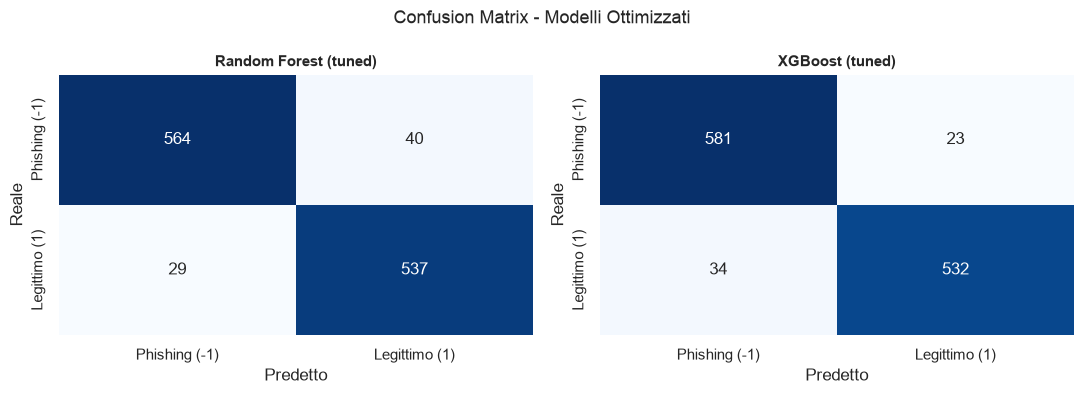

In [35]:
# Valutazione dei migliori estimatori sul test set
best_rf = grid_rf.best_estimator_
y_pred_rf_tuned = best_rf.predict(X_test)

best_xgb = rand_xgb.best_estimator_
y_pred_xgb_tuned = le.inverse_transform(best_xgb.predict(X_test))  # {0,1} -> {-1,1}

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
tuned = [('Random Forest (tuned)', y_pred_rf_tuned), ('XGBoost (tuned)', y_pred_xgb_tuned)]

print('=== MODELLI OTTIMIZZATI - TEST SET ===\n')
for ax, (name, y_pred) in zip(axes, tuned):
    acc  = accuracy_score(y_test, y_pred)
    prec = precision_score(y_test, y_pred, average='weighted')
    rec  = recall_score(y_test, y_pred, average='weighted')
    f1   = f1_score(y_test, y_pred, average='weighted')
    results.append({'Modello': name, 'Accuracy': acc, 'Precision': prec, 'Recall': rec, 'F1-Score': f1})
    plot_confusion_matrix(y_test, y_pred, title=name, ax=ax)
    print(f'--- {name} ---')
    print(f'  Accuracy:  {acc:.4f}')
    print(f'  Precision: {prec:.4f}')
    print(f'  Recall:    {rec:.4f}')
    print(f'  F1-Score:  {f1:.4f}\n')

plt.suptitle('Confusion Matrix - Modelli Ottimizzati', fontsize=13)
plt.tight_layout()
plt.show()

=== CLASSIFICA FINALE DEI MODELLI (per F1-Score) ===
                          Accuracy  Precision  Recall  F1-Score
Modello                                                        
XGBoost                     0.9530     0.9530  0.9530    0.9530
XGBoost (tuned)             0.9513     0.9514  0.9513    0.9513
Gradient Boosting           0.9462     0.9464  0.9462    0.9462
Random Forest (tuned)       0.9410     0.9412  0.9410    0.9410
Random Forest               0.9410     0.9412  0.9410    0.9410
Ensemble (Majority Vote)    0.9342     0.9343  0.9342    0.9342
Decision Tree               0.9188     0.9188  0.9188    0.9188
K-Nearest Neighbors         0.9179     0.9180  0.9179    0.9179
Logistic Regression         0.9120     0.9123  0.9120    0.9120


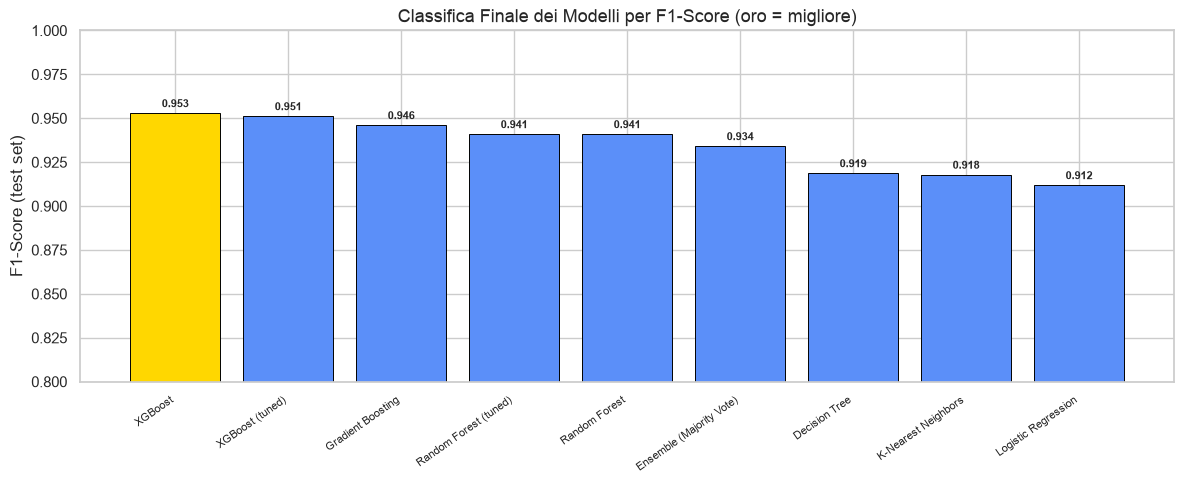


>>> Modello migliore: XGBoost (F1 = 0.9530)


In [36]:
# Confronto finale: tutti i modelli, ordinati per F1-Score
final_df = (pd.DataFrame(results)
            .drop_duplicates('Modello', keep='last')
            .set_index('Modello')
            .sort_values('F1-Score', ascending=False))

print('=== CLASSIFICA FINALE DEI MODELLI (per F1-Score) ===')
print(final_df.to_string(float_format='{:.4f}'.format))

plt.figure(figsize=(12, 5))
colors_final = ['#FFD700' if i == 0 else '#5B8FF9' for i in range(len(final_df))]
bars = plt.bar(final_df.index, final_df['F1-Score'], color=colors_final, edgecolor='black', linewidth=0.7)
plt.ylim(0.8, 1.0)
plt.ylabel('F1-Score (test set)')
plt.title('Classifica Finale dei Modelli per F1-Score (oro = migliore)', fontsize=13)
plt.xticks(rotation=35, ha='right', fontsize=8)
for bar in bars:
    h = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, h + 0.002, f'{h:.3f}',
             ha='center', va='bottom', fontsize=8, fontweight='bold')
plt.tight_layout()
plt.show()

best_overall = final_df.index[0]
print(f'\n>>> Modello migliore: {best_overall} (F1 = {final_df.iloc[0]["F1-Score"]:.4f})')

# **Fase 4 — Valutazione Critica e Discussione dei Risultati**

Il confronto quantitativo tra i modelli e l'identificazione del migliore sono presentati al termine della Fase 3 (classifica finale). Qui si approfondiscono l'**analisi degli errori** del modello migliore e la **discussione di limiti e bias**.

## **13. Analisi degli Errori del Modello Migliore**

XGBoost è risultato il modello migliore per F1-Score. Analizziamo qui *dove* sbaglia, distinguendo i due tipi di errore secondo la convenzione di sicurezza (classe positiva = phishing, `-1`):
- **Falso negativo (FN)**: sito di phishing classificato come legittimo → l'errore più pericoloso, espone l'utente all'attacco.
- **Falso positivo (FP)**: sito legittimo classificato come phishing → genera solo un falso allarme.

=== ANALISI DEGLI ERRORI - XGBoost ===

Errori totali: 55/1170 (4.70%)
  Falsi negativi (phishing -> legittimo): 25  [errore piu critico]
  Falsi positivi (legittimo -> phishing): 30

Profilo medio sulle feature piu discriminanti (corretti vs errati):
                   Classificati corretti (media)  Mal classificati (media)
SSLfinal_State                             0.137                     0.182
URL_of_Anchor                             -0.134                     0.055
having_Sub_Domain                          0.071                     0.200
Prefix_Suffix                             -0.749                    -1.000
web_traffic                                0.250                     0.345


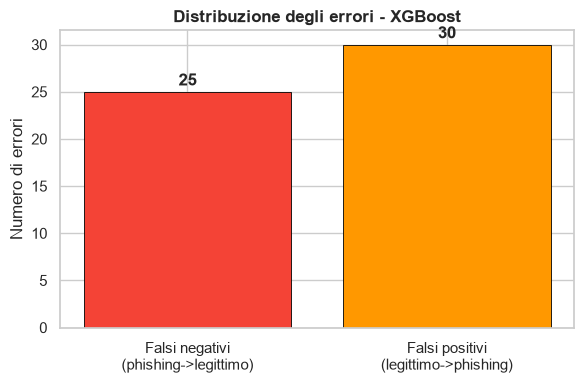

In [37]:
# === ANALISI DEGLI ERRORI DEL MODELLO MIGLIORE ===
best_name = 'XGBoost'  # miglior modello per F1-Score (vedi classifica finale)
y_pred_best = np.asarray(predictions[best_name])
y_true_arr  = np.asarray(y_test)

errors_mask = y_pred_best != y_true_arr
n_errors = int(errors_mask.sum())
n_total  = len(y_true_arr)

# Convenzione di sicurezza: classe positiva = phishing (-1)
fn_mask = (y_true_arr == -1) & (y_pred_best == 1)   # phishing sfuggito (falso negativo)
fp_mask = (y_true_arr == 1)  & (y_pred_best == -1)  # falso allarme (falso positivo)

print(f'=== ANALISI DEGLI ERRORI - {best_name} ===\n')
print(f'Errori totali: {n_errors}/{n_total} ({n_errors/n_total*100:.2f}%)')
print(f'  Falsi negativi (phishing -> legittimo): {int(fn_mask.sum())}  [errore piu critico]')
print(f'  Falsi positivi (legittimo -> phishing): {int(fp_mask.sum())}')

# Profilo medio dei campioni mal classificati sulle feature piu discriminanti
key_features = [f for f in ['SSLfinal_State', 'URL_of_Anchor', 'having_Sub_Domain',
                            'Prefix_Suffix', 'web_traffic'] if f in X_test.columns]
profile = pd.DataFrame({
    'Classificati corretti (media)': X_test[~errors_mask][key_features].mean(),
    'Mal classificati (media)':      X_test[errors_mask][key_features].mean(),
}).round(3)
print('\nProfilo medio sulle feature piu discriminanti (corretti vs errati):')
print(profile.to_string())

# Visualizzazione FP vs FN
fig, ax = plt.subplots(figsize=(6, 4))
vals = [int(fn_mask.sum()), int(fp_mask.sum())]
ax.bar(['Falsi negativi\n(phishing->legittimo)', 'Falsi positivi\n(legittimo->phishing)'],
       vals, color=['#F44336', '#FF9800'], edgecolor='black', linewidth=0.6)
ax.set_ylabel('Numero di errori')
ax.set_title(f'Distribuzione degli errori - {best_name}', fontweight='bold')
for i, v in enumerate(vals):
    ax.text(i, v + max(vals)*0.01, str(v), ha='center', va='bottom', fontweight='bold')
plt.tight_layout()
plt.show()

## **14. Discussione: Limiti e Bias**

Una lettura critica del lavoro richiede di riconoscerne i limiti.

- **Dataset statico e datato**: le tecniche di phishing evolvono rapidamente, quindi le prestazioni su traffico attuale potrebbero degradare (*concept drift*). Le metriche qui riportate valgono per la distribuzione del dataset, non necessariamente per il phishing odierno.
- **Feature pre-estratte**: le 30 feature sono già state estratte e discretizzate da terzi. Il modello eredita eventuali bias nella loro definizione e non è valutato end-to-end a partire dall'URL grezzo.
- **Bias di raccolta**: l'altissima percentuale iniziale di duplicati (~47%) segnala possibili distorsioni nella raccolta dei dati; la deduplicazione le mitiga ma non le elimina del tutto.
- **Singola sorgente dati**: la valutazione si basa su un unico dataset. Una validazione su dataset esterni e più recenti rafforzerebbe le conclusioni.
- **SMOTE su feature categoriche**: i campioni sintetici sono generati per interpolazione, scelta plausibile ma non sempre realistica per variabili categoriche/ordinali.

**Asimmetria dei costi**: dato che i falsi negativi sono più dannosi dei falsi positivi, in un sistema reale converrebbe spostare la soglia decisionale a favore del *recall* sulla classe phishing, accettando qualche falso allarme in più.

## **15. Conclusioni**

### Risposte alle Research Questions

- **RQ1 (feature discriminanti)**: tre evidenze indipendenti — distribuzione condizionata al target, correlazione col target e importanza Random Forest/RFE — concordano nell'indicare `SSLfinal_State` e `URL_of_Anchor` come le variabili più predittive, seguite da `having_Sub_Domain`, `Prefix_Suffix` e `web_traffic`.
- **RQ2 (impatto del data cleaning)**: la rimozione del 47% di duplicati è l'intervento più determinante, soprattutto per la *validità* delle stime (evita il data leakage train/test) oltre che per il riequilibrio delle classi.
- **RQ3 (ensemble vs modelli semplici)**: gli ensemble a boosting offrono un vantaggio chiaro ma non drastico (da ~91–92% di F1 dei modelli base al 95,3% di XGBoost): il segnale è in parte catturabile anche da modelli semplici, ma il boosting sfrutta meglio le interazioni tra feature.

### Data Cleaning - Risultati

Il processo di pulizia dei dati ha rappresentato la fase più critica del progetto:

- **Duplicati rimossi**: ~47% delle righe del dataset grezzo erano duplicati, una percentuale altissima che avrebbe distorto gravemente qualsiasi modello. La rimozione ha portato il dataset da 11.055 a 5.849 campioni.
- **Dominio dei valori**: tutte le feature rispettavano il dominio definito nello schema ARFF, con valori in {-1, 0, 1}. Nessuna violazione rilevata.
- **Valori mancanti**: nessun NaN classico presente. I valori `0` nelle feature ternarie sono semanticamente validi.
- **Feature quasi-costanti**: nessuna feature eliminata per varianza insufficiente, il che conferma la qualità informativa del dataset.
- **Correlazioni ridondanti**: una sola coppia ha superato la soglia |r| > 0.85 (`popUpWidnow` ↔ `Favicon`, |r| = 0.93); è stata rimossa `popUpWidnow`, mantenendo la feature più correlata col target. Il dataset finale ha quindi 29 feature.

### Modelli - Risultati

I modelli base (Decision Tree, Logistic Regression, KNN) e l'Ensemble raggiungono già prestazioni elevate grazie alla buona qualità del dataset pulito e all'applicazione di SMOTE per il bilanciamento.

### Miglioramenti Implementati

Rispetto alla versione iniziale, sono stati aggiunti i seguenti miglioramenti (sezioni 9-12):

- **Feature Selection automatizzata** (sez. 9): l'importanza secondo Random Forest e la Recursive Feature Elimination (RFE) concordano nell'identificare le feature più predittive (in particolare `SSLfinal_State`, `URL_of_Anchor`, `Prefix_Suffix`, `web_traffic`), confermando che il dataset pulito è composto da variabili informative.
- **Modelli avanzati** (sez. 10): Random Forest, Gradient Boosting e XGBoost superano i modelli base, con i metodi ensemble ad albero che ottengono le prestazioni migliori sui dati tabellari.
- **Validazione incrociata** (sez. 11): la 5-fold Stratified CV — con SMOTE inserito **dentro** la pipeline per evitare data leakage — fornisce una stima robusta delle prestazioni, confermando la stabilità dei risultati (deviazioni standard contenute).
- **Hyperparameter tuning** (sez. 12): GridSearchCV (Random Forest) e RandomizedSearchCV (XGBoost) hanno ottimizzato gli iperparametri, con i modelli ottimizzati valutati sul test set tenuto da parte.

La classifica finale (sez. 12.3) mostra che i modelli ensemble ottimizzati offrono il miglior compromesso tra accuratezza e robustezza.

### Sviluppi Futuri

- **Modelli ancora più avanzati**: LightGBM, CatBoost, o stacking/blending di più modelli.
- **Calibrazione delle probabilità** e analisi delle curve ROC/PR per tarare la soglia decisionale in funzione del costo dei falsi negativi (un sito di phishing non rilevato).
- **Interpretabilità**: analisi SHAP per spiegare le predizioni dei modelli ensemble.
- **Deployment**: esportazione del modello migliore (es. con `joblib`) e integrazione in un servizio di rilevamento in tempo reale.